# A Comparative Analysis of Policing Models in the Context of Baltimore

</br></br>


## Aims and Questions

This study investigates how policing models perform in the context of **Baltimore** — a racially segregated city with a complex policing history. We also compare traditional **hotspot-based policing (KDE)** and **model-based predictive policing (PredPol)** in terms of accuracy and fairness.

---

### Core Research Aims

#### Aim 1: Fairness and Accuracy Comparison
- How does KDE compare to PredPol in terms of **fairness** and **accuracy** across scenarios?
- Are more accurate systems necessarily fairer?

#### Aim 2: Temporal Feedback Loop Effects
- Does bias **amplify** over time?
- Do different systems respond differently to feedback loops?

#### Aim 3: Impact of Crime Type
- How does the choice of crime type (e.g., burglary vs total crimes) affect bias?

#### Aim 4: Is Bias Data-Driven or Model-Driven?
- What happens when the same data is used in different models?
- What happens when the same model is fed different data?

#### Aim 5: Baltimore-Specific Questions and Insights
This study uses real neighborhood geography and demographic data from Baltimore. We explore not only algorithmic fairness in general, but also how these algorithms behave in the context of a racially segregated city with a known history of policing disparity.
- Are police consistently concentrated in **racially defined neighborhoods** (Black-majority, White-majority, or Other), and if so, **which group receives more attention**?
- Are these outcomes explainable by the **number of neighborhoods per group**, or do they reflect **preferential targeting**?
- Are there **specific neighborhoods** that are consistently getting highest police-shares, regardless of the model used?



In [1]:
#next twoo for loading maps
import os
from IPython.display import IFrame

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from hashlib import md5
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress
from sklearn.metrics import r2_score
from statsmodels.tsa.stattools import acf
from hashlib import md5
from pymannkendall import original_test as mann_kendall


In [2]:
RRF= f'results/Final_Compare/2025-04-18__09-01-34/'
master_df= pd.read_csv(f'{RRF}Master_Res_sub.csv')
RRF= RRF +"plots/"
display(master_df)

,prediction_method,duration,crime_type,number_of_police,Algorithm,Neighborhood,Date,nextDate,pReport,CrimesNum,PoliceNum,DetectedNum,Intensity (lambda)
0,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.0,0.0,0.00,0.00,NaN
1,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.4,0.0,0.00,0.00,NaN
2,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-02,2019-01-03,0.0,0.0,0.00,0.00,NaN
3,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-02,2019-01-03,0.4,0.0,0.00,0.00,NaN
4,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-03,2019-01-04,0.0,0.0,0.00,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
274427,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-10-01,2021-11-01,0.4,3.0,0.05,0.05,0.000166
274428,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-11-01,2021-12-01,0.0,7.0,0.00,0.00,0.000172
274429,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-11-01,2021-12-01,0.4,7.0,0.00,0.00,0.000164
274430,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-12-01,2022-01-01,0.0,3.0,0.05,0.05,0.000170


In [3]:
df_neighood = pd.read_csv("Data Frames/Preprocessed/Neighborhoods_Residential.csv")

def assign_majority_race(row):
    if row["IsBlack"]:
        return "Black"
    elif row["IsWhite"]:
        return "White"
    else:
        return "Other"

df_neighood["Race"] = df_neighood.apply(assign_majority_race, axis=1)

display(df_neighood)

,Name,Population,White,Blk_AfAm,AmInd_AkNa,Asian,NatHaw_Pac,Other_Race,TwoOrMore,Hisp_Lat,SHAPE__Area,TotalNumberOfResidents,AllRaceExcptBlk,IsBlack,IsWhite,Boundaries,Race
0,ABELL,889.0000,606.0000,213.0000,3.0000,33.0000,1,4.000,29.0000,30.0000,3.163361e+05,890.0000,677.0000,False,True,"POLYGON ((-76.6111324007745 39.3234461864839,-...",White
1,ALLENDALE,3554.0000,18.0000,3497.0000,8.0000,6.0000,0,5.000,20.0000,21.0000,1.759173e+06,3555.0000,58.0000,True,False,"POLYGON ((-76.672627345299 39.2918441815671,-7...",Black
2,ARCADIA,1235.0000,623.0000,537.0000,4.0000,12.0000,0,10.000,49.0000,31.0000,9.800179e+05,1217.0000,680.0000,False,True,"POLYGON ((-76.5685271368632 39.335951205063,-7...",White
3,ARLINGTON,2598.0000,33.0000,2496.0000,3.0000,9.0000,0,10.000,47.0000,17.0000,7.832708e+05,2568.0000,72.0000,True,False,"POLYGON ((-76.6862655982037 39.3479128201721,-...",Black
4,ARMISTEAD GARDENS,3458.0000,2698.0000,108.0000,51.0000,14.0000,8,413.000,166.0000,841.0000,2.048122e+06,4133.0000,4025.0000,False,True,"POLYGON ((-76.5588020984783 39.3064645435754,-...",White
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,WRENLANE,628.6798,12.6746,603.0052,4.0000,0.0000,0,1.000,8.0000,12.0000,1.251045e+05,632.6798,29.6746,True,False,"POLYGON ((-76.6038454348344 39.3455311270785,-...",Black
252,WYMAN PARK,1141.0000,1016.0000,25.0000,1.0000,74.0000,0,3.000,22.0000,30.0000,4.784138e+05,1149.0000,1124.0000,False,True,"POLYGON ((-76.6259402689133 39.3311312297492,-...",White
253,WYNDHURST,702.0000,616.0000,31.0000,0.0000,24.0000,0,4.000,27.0000,24.0000,1.317835e+06,699.0000,668.0000,False,True,"POLYGON ((-76.6346837801626 39.3556027973729,-...",White
254,YALE HEIGHTS,2500.0000,196.0000,2202.0000,12.0000,27.0000,2,31.000,30.0000,41.0000,8.315513e+05,2511.0000,309.0000,True,False,"POLYGON ((-76.6929237211372 39.27249360663,-76...",Black


In [4]:
df_neighood["Race"].value_counts()

Black    168
White     85
Other      3
Name: Race, dtype: int64

In [5]:
master_df = master_df.merge(df_neighood[["Name", "Race","IsBlack", "IsWhite"]], left_on="Neighborhood", right_on="Name", how="left")
master_df = master_df.drop(columns=["Name"])
display(master_df)
master_df.info()


,prediction_method,duration,crime_type,number_of_police,Algorithm,Neighborhood,Date,nextDate,pReport,CrimesNum,PoliceNum,DetectedNum,Intensity (lambda),Race,IsBlack,IsWhite
0,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.0,0.0,0.00,0.00,NaN,White,False,True
1,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.4,0.0,0.00,0.00,NaN,White,False,True
2,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-02,2019-01-03,0.0,0.0,0.00,0.00,NaN,White,False,True
3,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-02,2019-01-03,0.4,0.0,0.00,0.00,NaN,White,False,True
4,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-03,2019-01-04,0.0,0.0,0.00,0.00,NaN,White,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274427,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-10-01,2021-11-01,0.4,3.0,0.05,0.05,0.000166,Black,True,False
274428,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-11-01,2021-12-01,0.0,7.0,0.00,0.00,0.000172,Black,True,False
274429,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-11-01,2021-12-01,0.4,7.0,0.00,0.00,0.000164,Black,True,False
274430,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-12-01,2022-01-01,0.0,3.0,0.05,0.05,0.000170,Black,True,False


<class 'pandas.core.frame.DataFrame'>
Int64Index: 274432 entries, 0 to 274431
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   prediction_method   274432 non-null  object 
 1   duration            274432 non-null  int64  
 2   crime_type          274432 non-null  object 
 3   number_of_police    274432 non-null  int64  
 4   Algorithm           274432 non-null  object 
 5   Neighborhood        274432 non-null  object 
 6   Date                274432 non-null  object 
 7   nextDate            274432 non-null  object 
 8   pReport             274432 non-null  float64
 9   CrimesNum           274432 non-null  float64
 10  PoliceNum           274432 non-null  float64
 11  DetectedNum         274432 non-null  float64
 12  Intensity (lambda)  240128 non-null  float64
 13  Race                274432 non-null  object 
 14  IsBlack             274432 non-null  bool   
 15  IsWhite             274432 non-nul

In [6]:
master_df.isna().sum()

prediction_method         0
duration                  0
crime_type                0
number_of_police          0
Algorithm                 0
Neighborhood              0
Date                      0
nextDate                  0
pReport                   0
CrimesNum                 0
PoliceNum                 0
DetectedNum               0
Intensity (lambda)    34304
Race                      0
IsBlack                   0
IsWhite                   0
dtype: int64

Following the legal 80% rule (p%-rule) [1] and as supported by Rahman et al.’s unified fairness framework [2], we define over-policing and under-policing using a ratio threshold of 1.2 and 0.8, respectively. This identifies neighborhoods that receive significantly more or less police presence than their share of crime would justify.

In [7]:
Eps =(1/2560) #number of Neighborhoods in Baltimore is 256

scenario_cols = ["Algorithm", "prediction_method", "crime_type", "number_of_police", "pReport"]
master_df["ScenarioID"] = master_df[scenario_cols].astype(str).agg("-".join, axis=1).apply(lambda x: md5(x.encode()).hexdigest())
master_df["Date"] = pd.to_datetime(master_df["Date"])
master_df["DayOfSim"] = (
    master_df.groupby("ScenarioID")["Date"]
    .transform(lambda x: x.rank(method="dense").astype(int) - 1)
)

master_df["TotalPoliceOfDay"] = master_df.groupby(["ScenarioID", "Date"])["PoliceNum"].transform("sum")
master_df["TotalCrimesOfDay"] = master_df.groupby(["ScenarioID", "Date"])["CrimesNum"].transform("sum")
master_df["TotalDetectedOfDay"] = master_df.groupby(["ScenarioID", "Date"])["DetectedNum"].transform("sum")

master_df["police_share"] = master_df["PoliceNum"] / master_df["TotalPoliceOfDay"]
master_df["crime_share"] = master_df["CrimesNum"] / master_df["TotalCrimesOfDay"]


master_df['CrimesNum_pEps'] = master_df['CrimesNum']+ Eps
master_df['PoliceNum_pEps'] = master_df["PoliceNum"]+ Eps
master_df['DetectedNum_pEps'] = master_df["DetectedNum"]+ Eps

master_df["TotalCrimesOfDay_pEps"] = master_df.groupby(["ScenarioID", "Date"])["CrimesNum_pEps"].transform("sum")
master_df["TotalPoliceOfDay_pEps"] = master_df.groupby(["ScenarioID", "Date"])["PoliceNum_pEps"].transform("sum")

"""Note: adding eps to all counts to avoid devision by zero:
Rule of succession if an event happens s times out of n times, 
the probability that it happens again is (s+1)/ (n+2).
check Dirichlet ...
"""
master_df["crime_share_pEps"] = master_df["CrimesNum_pEps"] / master_df["TotalCrimesOfDay_pEps"]
master_df["police_share_pEps"] = master_df["PoliceNum_pEps"] / master_df["TotalPoliceOfDay_pEps"]

master_df["cSh_per_pSh_smoothed"] = master_df["crime_share_pEps"] / master_df["police_share_pEps"]
master_df["pSh_per_cSh_smoothed"] = master_df["police_share_pEps"] / master_df["crime_share_pEps"]




master_df["coverage_accuracy_pEps"] = master_df['DetectedNum_pEps'] / master_df['CrimesNum_pEps']

#detection rate or efficiency accuracy: for this one I'm using actual counts without adding epsilon because detectedNum is zero if there is no police. 
master_df["detection_rate"] = master_df["DetectedNum"] / master_df["PoliceNum"].replace(0, np.nan)


#based on effective policing: police should be proportionate to crime
master_df["policeCrime_gap"] = master_df["police_share"] - master_df["crime_share"]



# master_df["over_policed"] = master_df["pSh_per_cSh_smoothed"] > 1
# master_df["under_policed"]= master_df["pSh_per_cSh_smoothed"] < 1

master_df["over_policed"] = master_df["police_share"] > (1.2 * master_df["crime_share"])
master_df["under_policed"]= master_df["police_share"] < (0.8 * master_df["crime_share"])

master_df["bias_flag"] = (master_df["over_policed"]) | (master_df["under_policed"])

display(master_df)

master_df.to_csv(f"{RRF}master_derived_df.csv", index=False)


,prediction_method,duration,crime_type,number_of_police,Algorithm,Neighborhood,Date,nextDate,pReport,CrimesNum,...,crime_share_pEps,police_share_pEps,cSh_per_pSh_smoothed,pSh_per_cSh_smoothed,coverage_accuracy_pEps,detection_rate,policeCrime_gap,over_policed,under_policed,bias_flag
0,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.0,0.0,...,0.000028,9.990409e-06,2.773050,0.360614,1.000000,NaN,0.000000,False,False,False
1,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.4,0.0,...,0.000028,9.990409e-06,2.773050,0.360614,1.000000,NaN,0.000000,False,False,False
2,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-02,2019-01-03,0.0,0.0,...,0.000023,1.044452e-05,2.187135,0.457219,1.000000,NaN,0.000000,False,False,False
3,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-02,2019-01-03,0.4,0.0,...,0.000023,1.041667e-05,2.192982,0.456000,1.000000,NaN,0.000000,False,False,False
4,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-03,2019-01-04,0.0,0.0,...,0.000026,1.006765e-05,2.569536,0.389175,1.000000,NaN,0.000000,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274427,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-10-01,2021-11-01,0.4,3.0,...,0.000930,1.259451e-04,7.384461,0.135420,0.016795,1.0,-0.000805,False,True,True
274428,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-11-01,2021-12-01,0.0,7.0,...,0.002281,9.763184e-07,2336.252354,0.000428,0.000056,NaN,-0.002281,False,True,True
274429,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-11-01,2021-12-01,0.4,7.0,...,0.002281,9.763184e-07,2336.252354,0.000428,0.000056,NaN,-0.002281,False,True,True
274430,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-12-01,2022-01-01,0.0,3.0,...,0.000934,1.259451e-04,7.416646,0.134832,0.016795,1.0,-0.000809,False,True,True


---
## Pre-Analysis
Before doing any analysis let's first look at some maps that were generated and saved during a simulation run. on these maps, dark-red circles are indicative of crimes in Black neighborhoods, black circles are crimes in white neighborhoods and green circles are in neighborhoods with majority of residents as neither black nor white, refered to as "Other". The blue markers are police locations assigned based on algorithms' results.

Due to the limited number of neighborhoods where 'Other' racial groups form the majority (3 neighborhoods), and these neighborhoods' low number of records in our crime dataset, including them in comparative statistical analysis would risk misleading interpretations. While these neighborhoods are not the focus of this particular quantitative comparison, their inclusion in broader fairness assessments remains essential, and future work should aim to better represent these communities

In [8]:
# p_method = 'Monthly' # or "Daily"
# c_type = "BURGLARY" # or "Total"
# alg = "KDE" # or "PredPol"
# map_path = os.path.join(f"{RRF}maps/{p_method}_{c_type}_{alg}/pReport_0.0.html")
# iframe = IFrame(src=map_path, width=650, height=600)
# display(iframe)

Checking out the maps, the bias potential is very clear with report probability equal to zero, i.e., when crime prediction and dispatching is based on discovered crime only and not reported crime. Therefor the data analysis from here on is when both discovered crimes and reported crimes are fed to the system for next periods predictions.

---
## Plots


In [9]:
CRIME_TYPES = ["BURGLARY", "TOTAL"]
POLICE_COUNTS = [40, 400]
ALGORITHMS = ["KDE", "Pred"]

COLORS = [
    "#f0b505",  # 0. yellow-gold
    "#D32F2F",  # 1. deep red
    "#055859",  # 2. teal
    "#5E5E5E",  # 3. medium-dark gray
    "#D1D1D1",  # 4. light gray
    "#0097A7",  # 5. cyan-teal
    "#6A1B9A",  # 6. deep purple
    "#F57C00",  # 7. burnt orange
    "#666666",  # 8. dark grey
]
palette_dict= {"KDE": COLORS[2],"Pred":COLORS[7], "Black":COLORS[3], "White":COLORS[0], "Other":COLORS[2]}
bcolor= COLORS[3]
wcolor= COLORS[0]
#ocolor = COLORS[5]
kde_color = COLORS[2]
pred_color = COLORS[7]


sns.set_context("notebook", font_scale=1.1)
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

def set_min_figsize(width=10, height=4):
    plt.gcf().set_size_inches(max(width, plt.gcf().get_size_inches()[0]),
                              max(height, plt.gcf().get_size_inches()[1]))


In [10]:
def calc_trendline_with_params(data):
    """
    data: is  a pd.series that has an index
    Calculate trendline along with its slope and y-intercept.
    """
    x = np.arange(len(data))
    slope, intercept = np.polyfit(x, data, 1)
    trendline = slope * x + intercept
    return trendline, slope, intercept

def calc_trendline(data):
    """
    data: is  a pd.series that has an index
    """
    x = np.arange(len(data))
    slope, intercept, _, _, _ = linregress(x, data.values)
    trendline = slope * x + intercept
    return trendline, slope


In [11]:
def plot_allocation_bars(df, pMethod="Monthly", alg="KDE", pRep= 0.0, pNum= 40, based_on="Average"):
    """
    based_on: has two options, "Average" or "Percentage"
    """
    for crime_type in CRIME_TYPES:
        data = df[(df["prediction_method"]==pMethod)&
                        (df["crime_type"]== crime_type)&
                        (df["Algorithm"]==alg)&
                        (df["number_of_police"]== pNum)&
                        (df["pReport"]==pRep)].copy()
        
        data["Black_Allocation"] = data["IsBlack"] * data["PoliceNum"]
        data["White_Allocation"] = data["IsWhite"] * data["PoliceNum"]
        #data["Other_Allocation"] = (~((data["IsWhite"]) | (data["IsBlack"]))) * data["PoliceNum"]
        
        data["Date"] = pd.to_datetime(data["Date"]).dt.date

#         allocation = data.groupby("Date")[["Black_Allocation", "White_Allocation","Other_Allocation"]].sum()
#         allocation[["Percentage_Black_Allocation","Percentage_White_Allocation","Percentage_Other_Allocation"]] = allocation.divide(allocation.sum(axis=1), axis=0) #axis=0 -> means rows => this line is dividing each row of the allocation by the sum of columns(axis=1) in that row
#         allocation[["Average_Black_Allocation","Average_White_Allocation","Average_Other_Allocation"]] = allocation[["Black_Allocation", "White_Allocation","Other_Allocation"]].divide([data["IsBlack"].sum(),data["IsWhite"].sum(), len(data["Race"]=="Other")], axis=1) #axis=0 -> means rows => this line is dividing each row of the allocation by the sum of columns(axis=1) in that row

#         allocation[[f"{based_on}_Black_Allocation",f"{based_on}_White_Allocation",f"{based_on}_Other_Allocation"]][:25].plot(kind="bar", figsize=(10, 4), color=[bcolor, wcolor,ocolor])
        
    
        allocation = data.groupby("Date")[["Black_Allocation", "White_Allocation"]].sum()
        allocation[["Percentage_Black_Allocation","Percentage_White_Allocation"]] = allocation.divide(allocation.sum(axis=1), axis=0) #axis=0 -> means rows => this line is dividing each row of the allocation by the sum of columns(axis=1) in that row
        allocation[["Average_Black_Allocation","Average_White_Allocation"]] = allocation[["Black_Allocation", "White_Allocation"]].divide([data["IsBlack"].sum(),data["IsWhite"].sum()], axis=1) #axis=0 -> means rows => this line is dividing each row of the allocation by the sum of columns(axis=1) in that row

        allocation[[f"{based_on}_Black_Allocation",f"{based_on}_White_Allocation"]][:25].plot(kind="bar", color=[bcolor, wcolor],figsize=(10, 4))#, 
        
        plt.title(f"{pMethod} Police Allocation by Neighborhood Race ({crime_type})")
        plt.ylabel(f"{based_on} of Officers Allocated")
        plt.xlabel("Date")
        plt.xticks(rotation=45)
        plt.legend(["Black Neighborhoods", "White Neighborhoods","Other"])
        
        plt.tight_layout()    
        save_title= f'{alg}_Police{based_on}_{pMethod}_{crime_type}_{pRep}_{pNum}'     
        plt.savefig(f'{RRF}/{save_title}.png')
        plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
        
        plt.show()

---

## Percentage of Police Allocated to Black vs. White Neighborhoods

This plot shows percentage of police allocated to Black neighborhoods Vs. White neighborhoods on each month by KDE, once using Burglaries and another time using all crimes, using only detected crimes. 


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


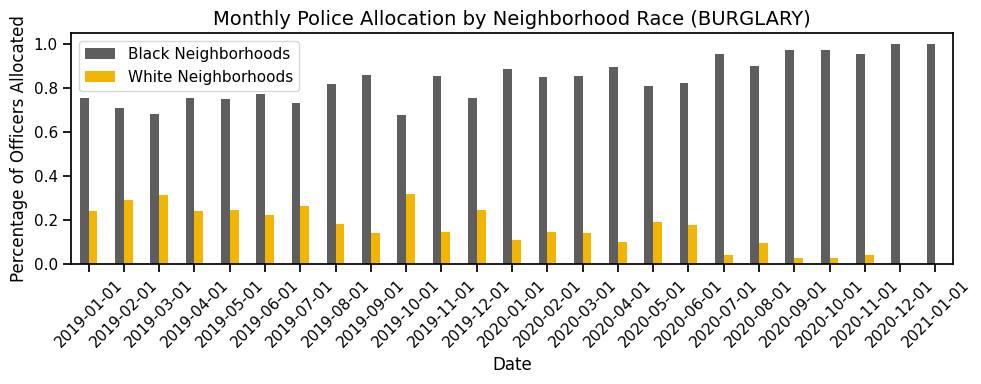

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


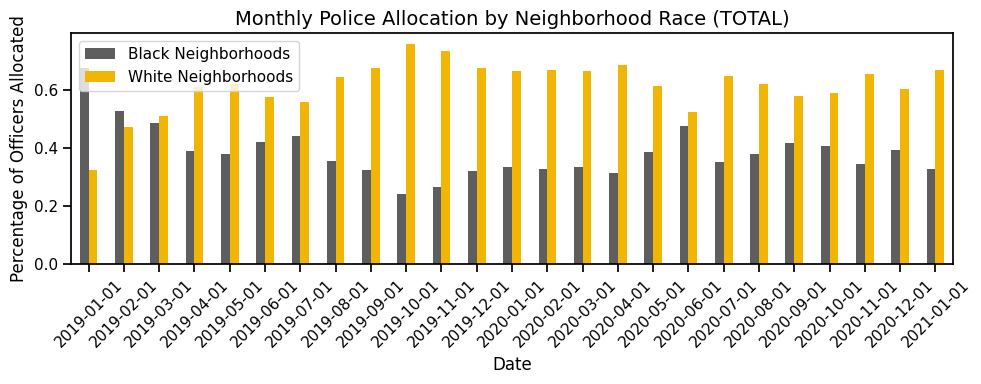

In [12]:
plot_allocation_bars(master_df,"Monthly","KDE",0.0, 40,"Percentage")

### Questions this plot answers:

#### Aim 2: Temporal Feedback Loop Effects
**1. Does bias amplify over time?** 

In this specific scenario, when Burglary records were used, we can see that as the days go on, more and more percentages of officers are assigned to Black neighborhoods, which could be an indication of amplification. In other scenarios, however, daily or monthly average police allocation is not showing a constant trend.

**2. Do different systems respond differently to feedback loops?** 

checking this plot over different scenarios, it is shown that: 
- KDE, when only detected crimes are used in Monthly police allocation settings, is either highly focused on black neighborhoods or white neighborhoods, based on the type of crime records used. 
- While KDE in other scenarios and Pred in all scenarios seem to focus on Black neighborhoods with little change in Police allocation percentage bars throughout the days/months.

#### Aim 3: Impact of Crime Type
**1. How does the choice of crime type (e.g., burglary vs total crimes) affect bias?**

Only in the case of Monthly prediction with KDE using all crime types' detected records (probability of report equal to zero) , and distributing 40 officers does the percentage of officers assigned to White neighborhoods remain higher than black neighborhoods throughout the simulation. In all other scenarios using both algorithms, this percentage is constantly higher for black neighborhoods.

#### Aim 5: Baltimore-Specific Questions and Insights
**2. Are these outcomes explainable by the number of neighborhoods per group, or do they reflect preferential targeting?**

Yes. We can not forget that Baltimore has **168 Black neighborhoods** and **85 White neighborhoods** so looking at mere percentages for Baltimore, in which the number of neighborhoods with different demographics isn't balanced, will lead us to inaccurate conclusions. So let's look at the average number of Police in Black Neighborhoods vs. White neighborhoods.

---

## Average Police-Number in Black vs. White Neighborhoods Across Crime-Types (Bar-Plot)

This plot is comparing Average police allocations to Black neighborhoods vs. White neighborhoods when All crime types' records are used vs. when only Burglary records are used over the days/months of simulation.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


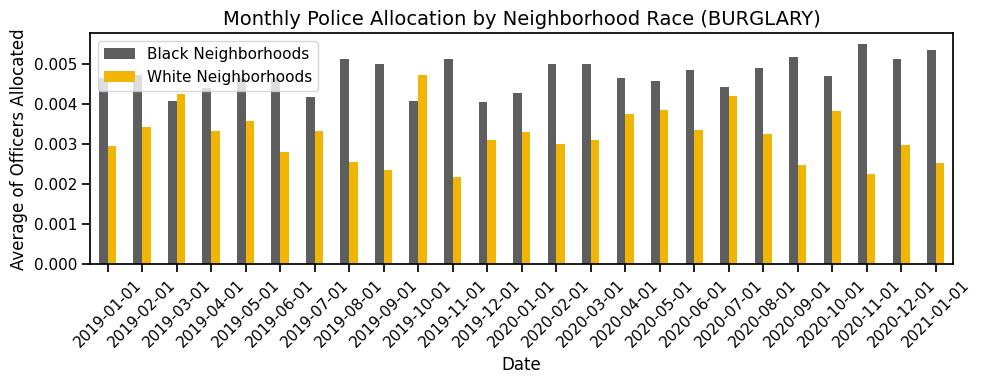

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


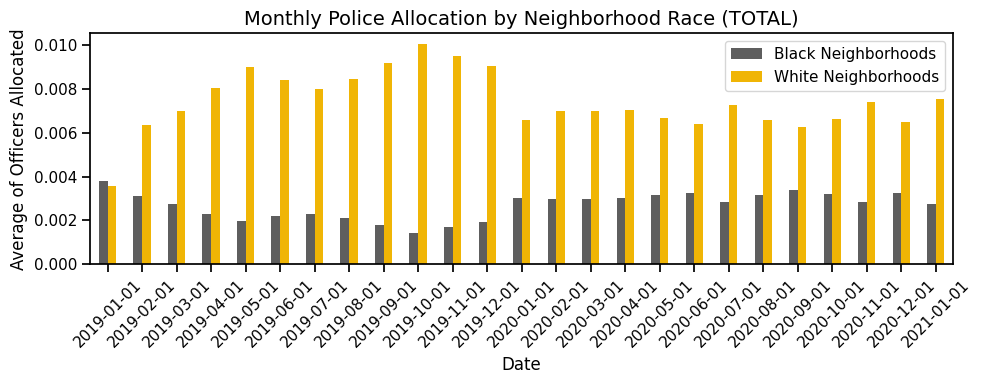

In [13]:
plot_allocation_bars(master_df,"Monthly","KDE",0.4,40,"Average" )

### Questions this plot answers:
#### Aim 2: Temporal Feedback Loop Effects

**1. Does bias amplify over time?** 

Looking at average police allocated to black neighborhood compared to white neighborhoods in the case of a monthly 40-officer allocation using KDE, with only detected crimes (report probability of zero), we see that when we use all crime types' records, as time passes average number of officers assigned to white neighborhoods grows, while for Black neighborhoods declines. However, using burglaries, this trend flips. Only these two scenarios could indicate amplification. Other scenarios there doesn't seem to be a constant growing or declining trend.</br> 

**2. Do different systems respond differently to feedback loops?** 

Based on the two scenarios of KDE with a trend, I guess for now I could say KDE seems to be more prone towards bias.

#### Aim 3: Impact of Crime Type
**1. How does the choice of crime type (e.g., burglary vs total crimes) affect bias?**

When using Burglaries, the average number of officers Black neighborhoods get is much more than white neighborhoods. While using all crime types, this difference is much less pronounced. 

Then there are **two extreme cases** of distributing 40 officers using the KDE model to fit **crime-record** datasets, in which **White neighborhoods** are getting about three times as many officers on average as Black neighborhoods. Therefore it is obvious that crime type does affect bias and where it concentrates resources. In the same situation as those two cases, when fitting KDE to **burglary records**, **Black neighborhoods** will have the highest average police numbers.

 
#### Aim 4: Is Bias Data-Driven or Model-Driven?
**1. What happens when the same data is used in different models?**

When KDE and PredPol were fed the same data, whether burglary or total crime, report probability of zero or 0.4, what was obvious was that Predpol showed less difference in the average number of officers allocated to black and white neighborhoods.

**2. What happens when the same model is fed different data?**

KDE's performance completely flips in response to different types of crime when the resource is scarce (40 officers). With higher resource numbers, although there's still a difference in police distribution, the concentration doesn't move from black neighborhood to white neighborhoods. 

PredPol, with either 40 officers or 400 officers, has more bias when trained on Burglaries compared to all crime types in all scenarios.

#### Aim 5: Baltimore-Specific Questions and Insights
**1. Are police consistently concentrated in racially defined neighborhoods (Black-majority, White-majority, or Other), and if so, which group receives more attention?**

In most scenarios, whether using KDE or PredPol, Black neighborhoods are getting a higher average of officers. When allocating based on Burglaries the difference is more severe. However, KDE on low officer resources, allocating based on all types of crime, filled white neighborhoods with a higher average of officers.

---

## Average Police-Share in Black vs. White Neighborhoods Across Algorithms (Line-Plot)
<!-- with Feedback Effect -->

This plot sets two algorithms' performance side-by-side, providing us with an understanding of the trends over the days for average share of officers in Black vs. White neighborhoods. 
<!-- We are also looking at the feedback effect. The feedback effect in this diagram is defined as the cumulative sum of first differences in the average number of officers over the days.
 -->


In [14]:
def plot_avg_police_share_with_feedback(pMethod="Monthly", pRep= 0.0, pNum= 40, cType="TOTAL"):
    for algorithm in ALGORITHMS:
        fig, ax = plt.subplots(figsize=(10, 6))#
        data = master_df[(master_df["prediction_method"]==pMethod)&
                        (master_df["crime_type"]== cType)&
                        (master_df["Algorithm"]==algorithm)&
                        (master_df["number_of_police"]== pNum)&
                        (master_df["pReport"]==pRep)].copy()


        daily_ratios = []
        for date, group in data.groupby("Date"):
            tp = int(group["TotalPoliceOfDay"].loc[group.index[0]])
            black_ratio = group[group["IsBlack"] == 1]["police_share"].mean()
            white_ratio = group[group["IsWhite"] == 1]["police_share"].mean()
            daily_ratios.append({"Date": date, "Black Neighborhoods": black_ratio, "White Neighborhoods": white_ratio, "TotalPoliceOfDay":tp})

        ratio_df = pd.DataFrame(daily_ratios).set_index("Date")
        ratio_df["Trendline (Black)"], black_slope = calc_trendline(ratio_df["Black Neighborhoods"])
        ratio_df["Trendline (White)"], white_slope = calc_trendline(ratio_df["White Neighborhoods"])

        ax.plot(ratio_df.index, ratio_df["Black Neighborhoods"], label="Black Neighborhoods", linestyle='-', color=bcolor)
        ax.plot(ratio_df.index, ratio_df["White Neighborhoods"], label="White Neighborhoods", linestyle='-', color=wcolor)
       
        ax.plot(ratio_df.index, ratio_df["Trendline (Black)"], label=f"Trendline (Black) (Slope: {black_slope:.6f})", linestyle='--', color='red')
        ax.plot(ratio_df.index, ratio_df["Trendline (White)"], label=f"Trendline (White) (Slope: {white_slope:.6f})", linestyle='--', color= COLORS[2])
        
        feedback_effect_black = (ratio_df["Black Neighborhoods"].diff().cumsum()).iloc[-1] #/ len(ratio_df)).iloc[-1]
        feedback_effect_white = (ratio_df["White Neighborhoods"].diff().cumsum() ).iloc[-1]#/ len(ratio_df)).iloc[-1]
        
#         ax.text(ratio_df.index[-5], 1.01*(ratio_df["Trendline (Black)"].iloc[-1]),
#                 f"Feedback Effect (Black): {feedback_effect_black:.4f}", fontsize=10, color='black')
#         ax.text(ratio_df.index[-5], 1.01*(ratio_df["Trendline (White)"].iloc[-1]),
#                 f"Feedback Effect (White): {feedback_effect_white:.4f}", fontsize=10, color='black')

        plt.title(f"Average Police Share ({algorithm}, {pNum} Officers)")
        plt.ylabel("Average Police Share")
        plt.xlabel("Date")
        plt.legend()
        plt.tight_layout()
        
        xticks = ratio_df.index[::5]
        plt.xticks(xticks, rotation=45)[::5]
        plt.tight_layout()
        
#         xtick_labels = [f"{d.strftime('%Y-%m-%d')}\nP: {ratio_df['TotalPoliceOfDay'].loc[d]}" for d in xticks]

#         ax.set_xticks(xticks)
#         ax.set_xticklabels(xtick_labels, rotation=45, ha="right")#, fontsize=9

        save_title = f'AvgPoliceShareWithFeedback_{algorithm}_{pMethod}_{cType}_{pRep}_{pNum}'
        plt.savefig(f'{RRF}/{save_title}.png')
        plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
        plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


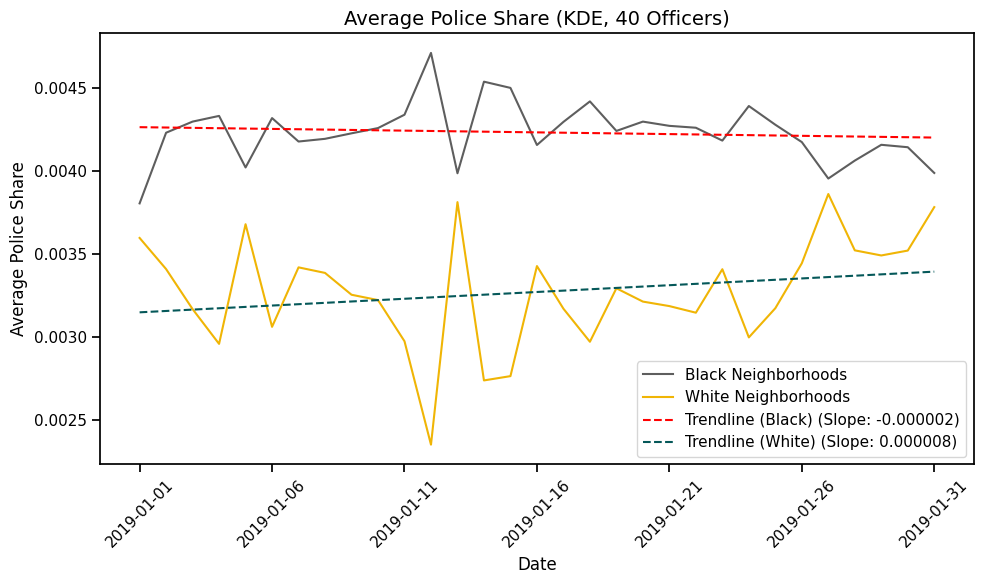

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


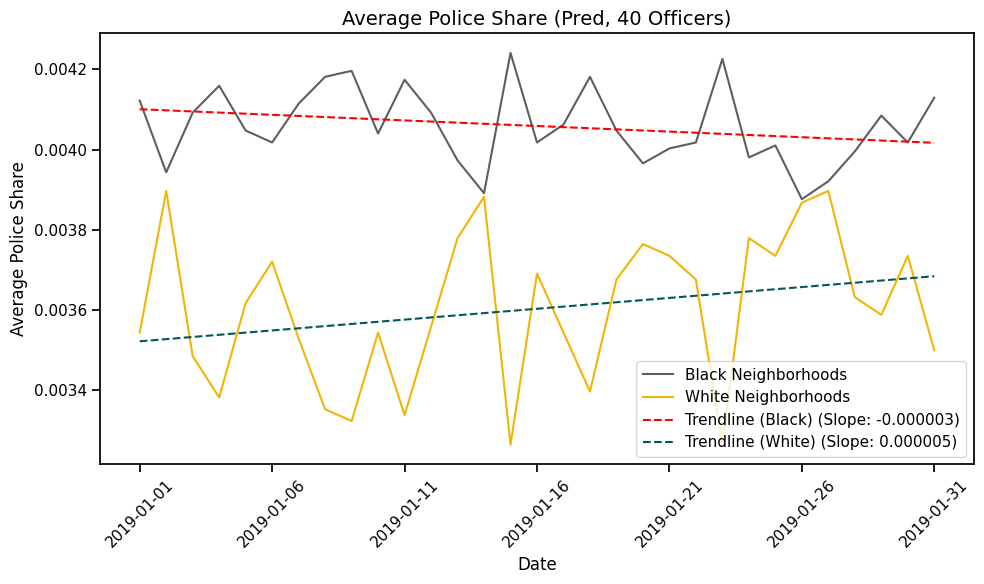

In [15]:
    plot_avg_police_share_with_feedback(pMethod="Daily", pRep= 0.4, pNum= 40, cType="TOTAL")

This is the last plot over which we are checking out monthly prediction because the difference in allocations for monthly prediction is much more obvious compared to daily prediction. Also, in the real world, these systems are mostly used for daily crime prediction and police allocations. So, to stay close to real-world scenarios, we focus on only daily predictions after this plot.

In all Daily prediction scenarios and about 62\% of Monthly prediction scenarios, black neighborhoods are getting the highest average of officers. However, when we talk about the feedback loop effect, we should look at the trendline because this effect comes out after enough feedback and should be analyzed with changes over time.

Looking at the slope of the trendline to determine whether the officers given to Black or White neighborhoods are increasing or decreasing, we see that when **all crime records** are used, the trend is toward assigning more officers in **White neighborhoods** in almost all scenarios ( Exception: PredPol 40 officers, 0.0 report probability). 

Using **burglary records**, though, the trend is a bit different in the cases of Monthly and Daily-predictions. For **monthly prediction**, the trend is toward Black except for cases of PredPol with 40 officers. In **daily predictions**, on the other hand, the trend is still mostly toward white, except for when 40 officers were used.


### Questions this plot answers:

#### Aim 4: Is Bias Data-Driven or Model-Driven?
**1. What happens when the same data is used in different models?**

Different models (KDE and PredPol) might act more a like given same data( All crime records)in some scenarios(400 officers) in terms of focusing on neighborhoods with specific demographics.However, even in those situations, the slope of trend and the extent of feedback effect is different.


**2. What happens when the same model is fed different data?** 

We saw that with all crime records the trend for PredPol was toward assigning more officers to white neighborhood, while in some scenarios (40 officers, 0.4 report probability) when burglary records were used its trend turned toward Black neighborhoods.

#### Aim 5: Baltimore-Specific Questions and Insights
**1. Are police consistently concentrated in racially defined neighborhoods (Black-majority, White-majority, or Other), and if so, which group receives more attention?**

In most of the scenarios with both algorithms higher average of officers are assigned to Black neighborhoods eventhough the trend is toward assigning more officers to White neighborhoods as the time passes.

**2. Are these outcomes explainable by the number of neighborhoods per group, or do they reflect preferential targeting?** 

The size of the groups stays the same in different simulations; however, the group with the highest police concentration changes in different scenarios. This suggests that the bias is not explainable by the number of neighborhoods, especially when the metric is averaged over number of neighborhoods in each demograhic.

### Note: For scenarios with monthly prediction method the bias is much more evident. </br><font color='red'> In analyzing plots from here on we focus solely on daily predictions. </font>

<!--
- Daily : Black has higher average share.
    - Total: in all but pred 40, 0.0, trend toward white
        - 0.0
            - 40
                - KDE:lowers (difference of two lines lowers
                - Pred: grows
            - 400
                - KDE: lowers
                - Pred:lowers
        - 0.4
            - 40
                - KDE:lowers
                - Pred:lowers
            - 400
                - KDE:lowers
                - Pred:lowers
    - Burglary: with high number of officers, trend toward white, with low number of officers trend toward black except fo pred, 40 , 0.0. 
        - 0.0
            - 40
                - KDE:grows ->trend toward black
                - Pred: lowers-> toward white
            - 400
                - KDE:lowers 
                - Pred: lowers
        - 0.4
            - 40
                - KDE:grows
                - Pred:grows-> toward black
            - 400
                - KDE:lowers
                - Pred:lowers
- Monthly: 
    - Total: wether black neighborhoods have the higher average or not, the trend is always toward white. 
        - 0.0
            - 40
                - KDE:white,  grows -> trend toward white
                - Pred:black,  lowers -> trend toward white
            - 400
                - KDE: sometimes black sometimes white, trend toward white  
                - Pred: black, lowers -> trend toward white
        - 0.4
            - 40
                - KDE:white, difference grows -> trend toward white
                - Pred:black,  lowers -> trend toward white
            - 400 
                - KDE: sometime black sometimes white , trend toward white
                - Pred: black, lowers -> trend toward white
    - Burglary: trend always toward black except for pred, 40 officer
        - 0.0
            - 40
                - KDE:black, grows ->trend toward black
                - Pred:black, lowers -> trend toward white
            - 400
                - KDE: sometime black sometimes white, TREND TOWARD BLACK
                - Pred:black, grows -> trend toward black
        - 0.4
            - 40
                - KDE:black, grows -> trend toward black
                - Pred:black, lowers -> trend toward white
            - 400
                - KDE:sometimes black, sometimes white, trend toward black
                - Pred:black, grows -> trend toward black
 -->          
---

## Standard Deviation of Police Numbers

This plot is comparing KDE and PredPol in terms of the changes in standard deviation of the number of officers assigned to each neighborhood throughout the simulation period. Police standard deviation is neither an accuracy metric nor a bias metric. However, it could show potential for bias. The lower the standard deviation, the higher the uniformity of officers' distribution. So if we have high standard deviation, we can assume that police concentration in some neighborhoods is higher compared to the rest, which could prove potential for bias.


In [16]:
def plot_std_dev(pMethod="Daily", pRep= 0.4, pNum= 40, cType="TOTAL"):
    for algorithm in ALGORITHMS:
        fig, ax = plt.subplots(figsize=(10, 6))#
        data = master_df[(master_df["prediction_method"]==pMethod)&
                        (master_df["crime_type"]== cType)&
                        (master_df["Algorithm"]==algorithm)&
                        (master_df["number_of_police"]== pNum)&
                        (master_df["pReport"]==pRep)].copy()

        std_dev = data.groupby("Date")["PoliceNum"].std()

        ax.plot(std_dev.index, std_dev, label=f"{algorithm}, {pNum} Officers", color=COLORS[8], linewidth=3)#COLORS[9]
        
        std_dev= std_dev
        trendline, slope = calc_trendline(std_dev)
        ax.plot(std_dev.index, trendline, label=f"Trendline (slope={slope:.3f})", linestyle='--', color='red', linewidth=2)
        
        """
        midpoint = len(std_dev) // 2
        std_dev1= std_dev[:midpoint]
        trendline1, slope1 = calc_trendline(std_dev1)
        ax.plot(std_dev1.index, trendline1, label=f"Trendline 1 (slope={slope1:.3f})", linestyle='--', color='red', linewidth=2)
        
        std_dev2= std_dev[midpoint:]
        trendline2, slope2 = calc_trendline(std_dev2)
        ax.plot(std_dev2.index, trendline2, label=f"Trendline 2 (slope={slope2:.3f})", linestyle='--', color='red', linewidth=2)
"""
        ax.set_title(f"Standard Deviation of Police Distribution Over Time ({algorithm})")
        ax.set_xlabel("Date")
        ax.set_ylabel("Standard Deviation")
        ax.legend()
        xticks = std_dev.index[::5]  
        plt.xticks(xticks, rotation=45)

        plt.tight_layout()
        save_title = f'PoliceStdDev_{algorithm}_{pMethod}_{cType}_{pNum}_{pRep}'
        plt.savefig(f'{RRF}/{save_title}.png')
        plt.savefig(f'{RRF}/{save_title}.eps', format='eps')

        plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


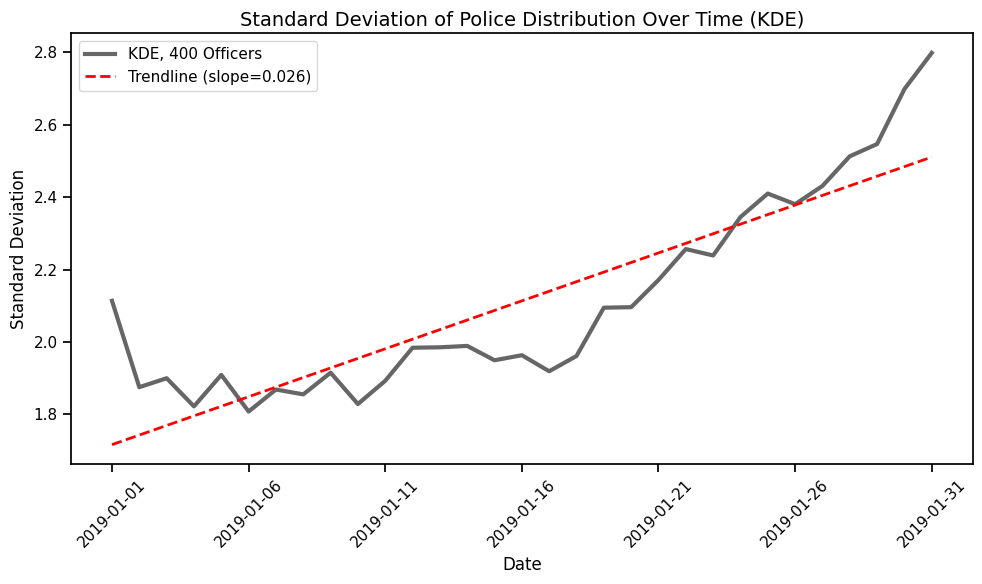

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


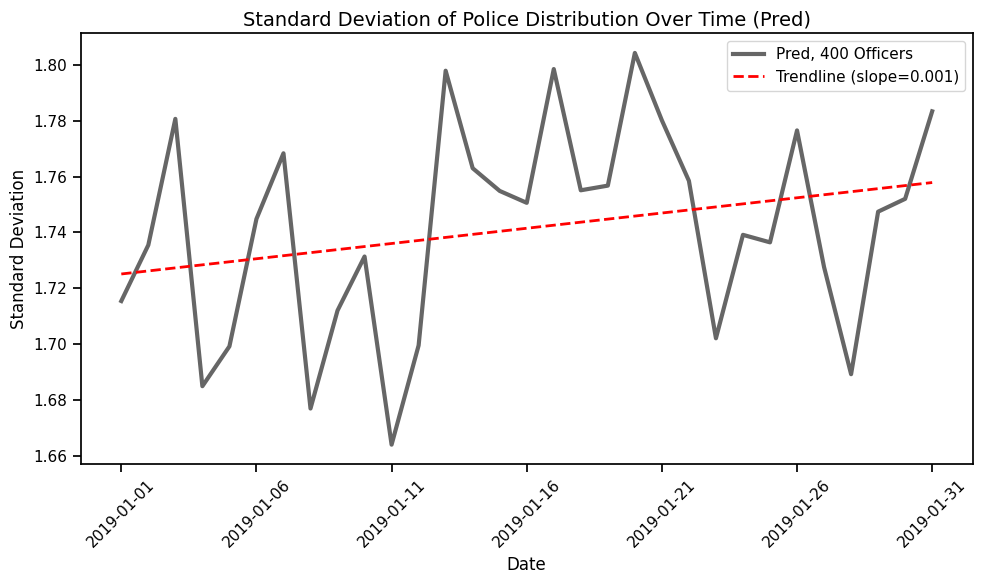

In [17]:
plot_std_dev(pMethod="Daily", pRep= 0.4, pNum= 400, cType="TOTAL")

### Questions this plot answers:
#### Aim 1: Fairness and Accuracy Comparison
**1. How does KDE compare to PredPol in terms of fairness and accuracy across scenarios?**

since standard deviation is **not** exactly a fairness metric, here we analyzed potential for bias. In all scenarios, KDE's trendline has a steeper slope compared to PredPol, showing more intensity of changes in the uniformity of police distribution among neighborhoods. Looking at KDE's plots in different scenarios, we could see the trend visually even without a trendline. PredPol, on the other hand, fluctuated so much in some of the scenarios that without a trendline it wouldn't have been easy to determine if there's a rising or declining trend, especially since the range of values for officers' standard deviations is much smaller for PredPol.

#### Aim 2: Temporal Feedback Loop Effects
**1. Does bias amplify over time?**

The potential for bias seems clear for KDE. For Predpol though, despite the mostly positive trendline slope, due to the fluctuations, concluding on this matter will be left after analyzing more diagrams. 

**2. Do different systems respond differently to feedback loops?** 

Yes, Predpol and KDE are showing a clear difference in the uniformity of police distribution.

<!-- #### Aim 4: Effect of Report Probability
**1. How does under-reporting affect model performance and fairness?** 

In most scenarios, by changing report probability from 0 to 1, the slope of the trendline decreased, meaning higher report probability lowers the potential for bias.

negative slopes:
Pred, BURGLARY, 40
Pred, TOTAL, 40, 0.4


 -->
 
 ---
 
 ## Answering Further Questions:

In [18]:
scenario_cols= ["Algorithm", "prediction_method", "number_of_police", "crime_type", "pReport"]
std_slope_records = []

for scenario_id, group in master_df.groupby(scenario_cols):
    group = group.sort_values("Date")
    x = np.arange(len(group["Date"].unique()))
    stds = group.groupby("Date")["PoliceNum"].std().values
    slope, *_ = linregress(x, stds)
    std_slope_records.append({
        **dict(zip(scenario_cols,scenario_id )),
        "std_slope": slope
    })

std_slope_df = pd.DataFrame(std_slope_records)

for col in scenario_cols:
    sc= scenario_cols.copy()
    sc.remove(col)
    pv= std_slope_df.pivot_table(
        index= sc,
        columns= col,
        values= "std_slope"
    ).reset_index()
    slope_cols= std_slope_df[col].unique()
    pv["higher?"]= pv[slope_cols].abs().idxmax(axis=1)
    vc= pv["higher?"].value_counts()
    print(f" Trying {len(pv)} scenarios with different '{col}': \n In {vc.max()/len(pv)*100:.1f}% of the scenarios, '{vc.idxmax()}' has higher slope.\n")

print("\nThe only scenarios where police standard deviation has a negative slope of trendline over the days are:")
neg_df = std_slope_df[std_slope_df["std_slope"] < 0]
display(neg_df)



 Trying 16 scenarios with different 'Algorithm': 
 In 100.0% of the scenarios, 'KDE' has higher slope.

 Trying 16 scenarios with different 'prediction_method': 
 In 100.0% of the scenarios, 'Monthly' has higher slope.

 Trying 16 scenarios with different 'number_of_police': 
 In 100.0% of the scenarios, '400' has higher slope.

 Trying 16 scenarios with different 'crime_type': 
 In 50.0% of the scenarios, 'BURGLARY' has higher slope.

 Trying 16 scenarios with different 'pReport': 
 In 68.8% of the scenarios, '0.0' has higher slope.


The only scenarios where police standard deviation has a negative slope of trendline over the days are:


,Algorithm,prediction_method,number_of_police,crime_type,pReport,std_slope
16,Pred,Daily,40,BURGLARY,0.0,-0.000044
17,Pred,Daily,40,BURGLARY,0.4,-0.000026
19,Pred,Daily,40,TOTAL,0.4,-0.000054


Looking at these stats, we can conclude that the choice of Algorithm, the length of period we distribute officers for, and the number of officers we distribute might have an impact on the potential for bias. 

I imagine we might see higher individual fairness values for scenarios using PredPol, Daily Prediction, and 40 officers in later plots. 

---

## Creating RacialDay_df



In [19]:
racialDay_df = master_df.groupby(scenario_cols+["ScenarioID", "Date", "Race"]).agg(
    race_total_police=("PoliceNum", "sum"),
    avg_police_num=("PoliceNum", "mean"),
    avg_police_share=("police_share", "mean"),
    avg_crime_share=("crime_share", "mean"),
    Average_policeCrime_gap=("policeCrime_gap", "mean"),
    Total_policeCrime_gap=("policeCrime_gap", "sum")
).reset_index()

total_police_per_day = master_df.groupby(["ScenarioID", "Date"])["PoliceNum"].sum().reset_index()
total_police_per_day.rename(columns={"PoliceNum": "TotalPoliceOfDay"}, inplace=True)

racialDay_df = racialDay_df.merge(total_police_per_day, on=["ScenarioID", "Date"], how="left")

racialDay_df["pct_total_police"] = racialDay_df["race_total_police"] / racialDay_df["TotalPoliceOfDay"]


display(racialDay_df)


,Algorithm,prediction_method,number_of_police,crime_type,pReport,ScenarioID,Date,Race,race_total_police,avg_police_num,avg_police_share,avg_crime_share,Average_policeCrime_gap,Total_policeCrime_gap,TotalPoliceOfDay,pct_total_police
0,KDE,Daily,40,BURGLARY,0.0,2094b54b00ec749eead26edfa81d26de,2019-01-01,Black,28.00,0.166667,0.004274,0.004252,0.000022,0.003663,39.0,0.717949
1,KDE,Daily,40,BURGLARY,0.0,2094b54b00ec749eead26edfa81d26de,2019-01-01,Other,2.00,0.666667,0.017094,0.000000,0.017094,0.051282,39.0,0.051282
2,KDE,Daily,40,BURGLARY,0.0,2094b54b00ec749eead26edfa81d26de,2019-01-01,White,9.00,0.105882,0.002715,0.003361,-0.000646,-0.054945,39.0,0.230769
3,KDE,Daily,40,BURGLARY,0.0,2094b54b00ec749eead26edfa81d26de,2019-01-02,Black,26.60,0.158333,0.004245,0.004202,0.000043,0.007254,37.3,0.713137
4,KDE,Daily,40,BURGLARY,0.0,2094b54b00ec749eead26edfa81d26de,2019-01-02,Other,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,37.3,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3211,Pred,Monthly,400,TOTAL,0.4,f99a3e133ffcc4336a0dd6f5ecd7c1bc,2021-11-01,Other,4.75,1.583333,0.003958,0.004779,-0.000821,-0.002462,400.0,0.011875
3212,Pred,Monthly,400,TOTAL,0.4,f99a3e133ffcc4336a0dd6f5ecd7c1bc,2021-11-01,White,124.65,1.466471,0.003666,0.003423,0.000243,0.020651,400.0,0.311625
3213,Pred,Monthly,400,TOTAL,0.4,f99a3e133ffcc4336a0dd6f5ecd7c1bc,2021-12-01,Black,271.70,1.617262,0.004043,0.004142,-0.000099,-0.016578,400.0,0.679250
3214,Pred,Monthly,400,TOTAL,0.4,f99a3e133ffcc4336a0dd6f5ecd7c1bc,2021-12-01,Other,5.65,1.883333,0.004708,0.003113,0.001595,0.004785,400.0,0.014125


## Daily Coverage Accuracy and Racial fairness
This diagram plots three metrics:

1. Racial Fairness: The difference between Average Police-Crime Gap(APCG) or Total Police-Crime Gap(TPCG) of Black and White neighborhoods (A/TPCG(Black)-A/TPCG(White))
2. Absolute Racial Fairness
3. Coverage Accuracy: percentage of crimes that are detected

In [20]:
def plot_coverageAccuracy_and_RacialFairness(pMethod="Daily", pRep=0.4, pNum=40, cType="TOTAL", based_on="Average"):
    """
    based_on: 'Average' or 'Total' → determines which racial fairness gap to plot (APCG or TPCG)
    """
    races = ["Black", "White"]
    df = racialDay_df[
        (racialDay_df["prediction_method"] == pMethod) &
        (racialDay_df["pReport"] == pRep) &
        (racialDay_df["number_of_police"] == pNum) &
        (racialDay_df["crime_type"] == cType) &
        (racialDay_df["Race"].isin(races))
    ].copy()

    pivoted = df.pivot_table(
        index=["Date", "Algorithm"],
        columns="Race",
        values=[f"{based_on}_policeCrime_gap"],
        aggfunc="mean"
    ).reset_index()
    pivoted.columns = ["Date", "Algorithm", "Black", "White"]
    pivoted[f"racial_fairness_gap_{based_on}PCG"] = pivoted["Black"] - pivoted["White"]
    pivoted[f"abs_racial_fairness_gap_{based_on}PCG"] = pivoted[f"racial_fairness_gap_{based_on}PCG"].abs()
    coverage_df = master_df[
        (master_df["prediction_method"] == pMethod) &
        (master_df["pReport"] == pRep) &
        (master_df["number_of_police"] == pNum) &
        (master_df["crime_type"] == cType)
    ].groupby(["Date", "Algorithm"]).agg(
        TotalCrime=("CrimesNum", "sum"),
        TotalDetected=("DetectedNum", "sum")
    ).reset_index()
    coverage_df["coverage_accuracy"] = coverage_df["TotalDetected"] / coverage_df["TotalCrime"]
    base_df = pivoted.merge(coverage_df, on=["Date", "Algorithm"], how="inner")

    for metric, label in {
         f"abs_racial_fairness_gap_{based_on}PCG": f"Abs. Racial Fairness Gap ({based_on} PCG)",
        f"racial_fairness_gap_{based_on}PCG": f"Racial Fairness Gap (Black - White {based_on} PCG)",
        "coverage_accuracy": "Coverage Accuracy"
    }.items():
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.lineplot(
            data=base_df,
            x="Date",
            y=metric,
            hue="Algorithm",
            palette=palette_dict,
            ax=ax,
            linewidth=2,
            errorbar=None
        )
        for algo in base_df["Algorithm"].unique():
            df_algo = base_df[base_df["Algorithm"] == algo]
            trend, slope = calc_trendline(df_algo[metric])
            ax.plot(df_algo["Date"], trend, linestyle="--", linewidth=2, color=palette_dict[algo], label=f"{algo} Trend (slope: {slope:.6f})")

        ax.set_title(f"{label} Over Time")
        ax.axhline(0, color="gray", linestyle="--", linewidth=1)
        ax.set_ylabel(label)
        ax.tick_params(axis="x", rotation=45)
        ax.set_ylim(base_df[metric].min(), base_df[metric].max())
        ax.legend()
        plt.tight_layout()

        save_title = f"{metric}_OverTime_{pRep}_{pMethod}_{cType}_{pNum}"
        plt.savefig(f"{RRF}/{save_title}.png")
        plt.savefig(f"{RRF}/{save_title}.eps", format="eps")
        plt.show()
       


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


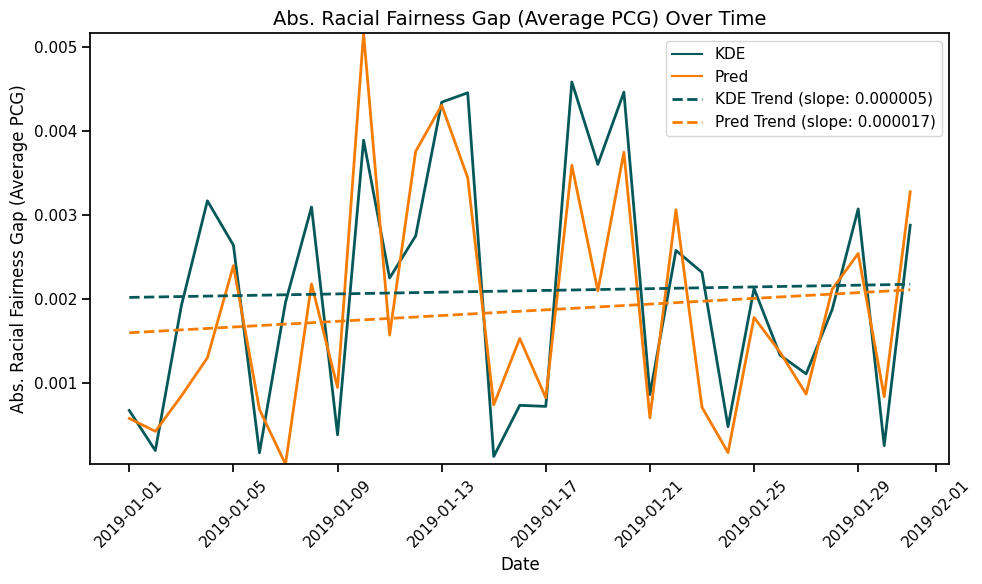

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


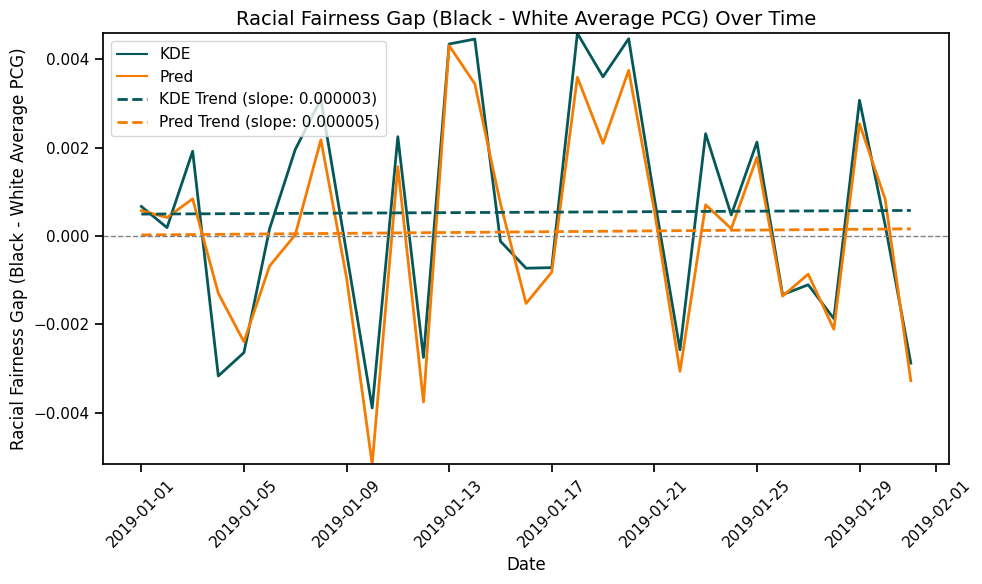

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


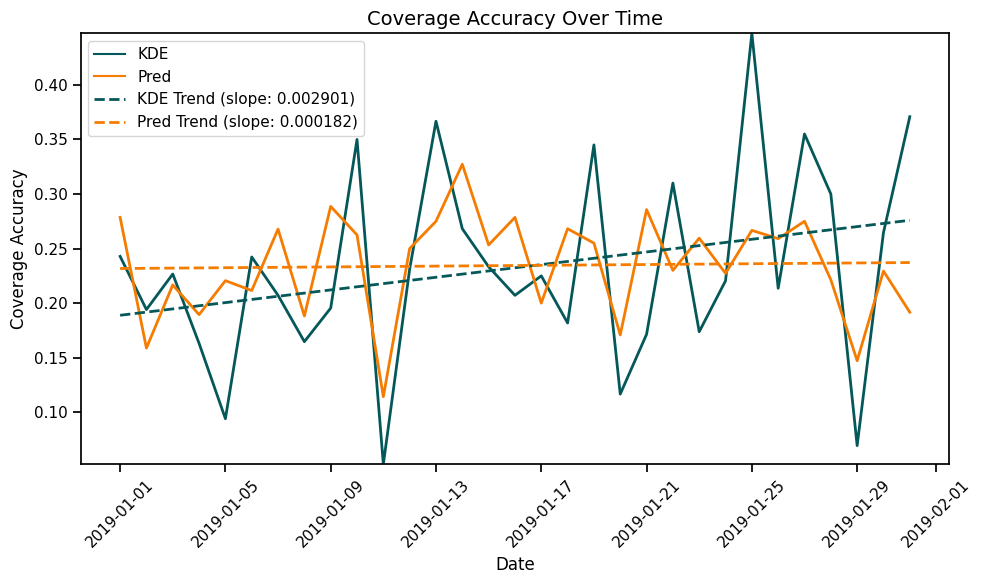

In [21]:
plot_coverageAccuracy_and_RacialFairness(pMethod="Daily", pRep=0.4, pNum=40, cType="BURGLARY", based_on="Average")


## Comparing Algorithms' Behvaior Based on These Metrics in Different Settings

In [22]:
scenario_cols = ["prediction_method", "crime_type", "number_of_police", "pReport","Algorithm"]
races = ["Black", "White"]

racial_gap_df = racialDay_df[racialDay_df["Race"].isin(races)].copy()

pivoted = racial_gap_df.pivot_table(
    index=scenario_cols+["Date"],
    columns="Race",
    values=["Average_policeCrime_gap"],
    aggfunc="mean"
).reset_index()

pivoted.columns = scenario_cols+["Date", "PCG_Black", "PCG_White"]
pivoted["racial_fairness_gap"] = pivoted["PCG_Black"] - pivoted["PCG_White"]
pivoted["abs_racial_fairness_gap"] = pivoted["racial_fairness_gap"].abs()

pivoted["race_preference"] = pivoted["racial_fairness_gap"].apply(lambda x: "Black" if x > 0 else "White" if x < 0 else "Neutral")

accuracy_df = master_df.groupby(scenario_cols+["Date"]).agg(
    total_crimes=("CrimesNum", "sum"),
    total_detected=("DetectedNum", "sum")
).reset_index()
accuracy_df["coverage_accuracy"] = accuracy_df["total_detected"] / accuracy_df["total_crimes"]

merged = pivoted.merge(accuracy_df, on=scenario_cols+["Date"], how="inner")

summary_records = []

for vals, group in merged.groupby(scenario_cols):
    group = group.sort_values("Date")
    x = np.arange(len(group))
    
    fair_slope, fair_intercept, *_ = linregress(x, group["abs_racial_fairness_gap"])
    fair_trend = "Improving" if fair_slope < 0 else "Worsening"

    race_trend_slope, *_ = linregress(x, group["racial_fairness_gap"])
    toward_race = "Black" if race_trend_slope > 0 else "White" if race_trend_slope < 0 else "Neutral"
    
    blackFocus= group["racial_fairness_gap"] > 0
    blackFocusPercentage= 100 * blackFocus.mean()
    curr_race_focus = "Black" if blackFocusPercentage > 50 else "White" if blackFocusPercentage < 50 else "Neutral",
    
    acc_slope, acc_intercept, *_ = linregress(x, group["coverage_accuracy"])
    acc_trend = "Improving" if acc_slope > 0 else "Worsening"

    summary_records.append({
        **dict(zip(scenario_cols, vals)), #the two stars behind dict inline-inserts dictionary key-value pairs into the other dictionary
        "avg_Abs_Racial_Fgap": group["abs_racial_fairness_gap"].mean(),
        "avg_Racial_Fgap": group["racial_fairness_gap"].mean(),
        "avg_accuracy": group["coverage_accuracy"].mean(),
        "racial_fairness_trend": fair_trend,
        "abs_racial_fairnessGap_slope": fair_slope,
        "racial_fairnessGap_slope": race_trend_slope,
        "race_policeFocus_direction": toward_race,
        "race_policeFocus_in_sim": curr_race_focus[0],
        "accuracy_trend": acc_trend,
        "accuracy_slope": acc_slope
    })
summary_racial_df = pd.DataFrame(summary_records)
display(summary_racial_df[summary_racial_df["prediction_method"]=="Daily"])


,prediction_method,crime_type,number_of_police,pReport,Algorithm,avg_Abs_Racial_Fgap,avg_Racial_Fgap,avg_accuracy,racial_fairness_trend,abs_racial_fairnessGap_slope,racial_fairnessGap_slope,race_policeFocus_direction,race_policeFocus_in_sim,accuracy_trend,accuracy_slope
0,Daily,BURGLARY,40,0.0,KDE,0.002121,0.000472,0.220627,Worsening,1.122528e-05,-0.000001,White,Black,Improving,0.002003
1,Daily,BURGLARY,40,0.0,Pred,0.001758,0.000071,0.227830,Worsening,1.221351e-05,-0.000013,White,Black,Improving,0.000515
2,Daily,BURGLARY,40,0.4,KDE,0.002096,0.000537,0.232403,Worsening,5.214832e-06,0.000003,Black,Black,Improving,0.002901
3,Daily,BURGLARY,40,0.4,Pred,0.001852,0.000093,0.234463,Worsening,1.708797e-05,0.000005,Black,Black,Improving,0.000182
4,Daily,BURGLARY,400,0.0,KDE,0.001932,0.000668,0.462165,Worsening,7.592012e-06,-0.000008,White,Black,Worsening,-0.000648
5,Daily,BURGLARY,400,0.0,Pred,0.001790,0.000136,0.648841,Worsening,1.117495e-05,-0.000004,White,Black,Improving,0.000477
6,Daily,BURGLARY,400,0.4,KDE,0.001909,0.000609,0.448883,Worsening,5.682300e-06,-0.000010,White,Black,Worsening,-0.000388
7,Daily,BURGLARY,400,0.4,Pred,0.001811,0.000173,0.645120,Worsening,1.091995e-05,-0.000005,White,Black,Improving,0.001861
8,Daily,TOTAL,40,0.0,KDE,0.000853,0.000206,0.208171,Worsening,1.074988e-05,-0.000036,White,Black,Improving,0.000830
9,Daily,TOTAL,40,0.0,Pred,0.000847,-0.000176,0.225532,Improving,-9.601038e-07,0.000012,Black,White,Improving,0.000232


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


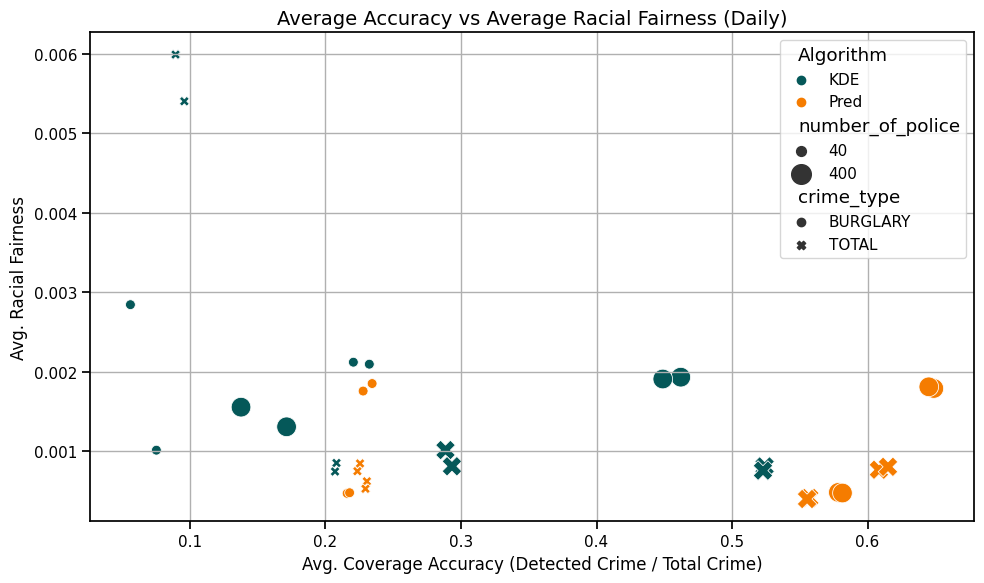

In [23]:
subset = summary_racial_df.copy()
# [
#     summary_df["pReport"]==0.4
# ].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=subset,
    x="avg_accuracy",
    y="avg_Abs_Racial_Fgap",
    hue="Algorithm",
    style="crime_type", 
    size="number_of_police",
    sizes=(50, 200),
    palette=palette_dict
)

plt.title("Average Accuracy vs Average Racial Fairness (Daily)")
plt.xlabel("Avg. Coverage Accuracy (Detected Crime / Total Crime)")
plt.ylabel("Avg. Racial Fairness")
plt.grid(True)

plt.tight_layout()
    
save_title = f'ScenarioCompare_AvgAccuracy_Vs_AvgRacialFairness'
plt.savefig(f'{RRF}/{save_title}.png')
plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
plt.show()


---

## Closer Look at Daily Racial Fairness and Accuracy Stats

In [24]:
final_records = []

for vals, group in summary_racial_df.groupby(["prediction_method", "crime_type", "number_of_police", "pReport"]):
    kde = group[group["Algorithm"] == "KDE"].iloc[0]
    pred = group[group["Algorithm"] == "Pred"].iloc[0]

    def trend_speed(slope1, slope2):
        return "KDE" if abs(slope1) > abs(slope2) else "Pred"

    final_records.append({
        **dict(zip(["prediction_method", "crime_type", "number_of_police", "pReport"], vals)),
        
        "Fairer_Algorithm": "KDE" if kde["avg_Abs_Racial_Fgap"] < pred["avg_Abs_Racial_Fgap"] else "Pred",
        "More_Accurate_Algorithm": "KDE" if kde["avg_accuracy"] > pred["avg_accuracy"] else "Pred",

        "KDE_Racial_Fairness_Trend": kde["racial_fairness_trend"],
        "Pred_Racial_Fairness_Trend": pred["racial_fairness_trend"],

        "KDE_Police_Focus_Trend": kde["race_policeFocus_direction"],
        "Pred_Police_Focus_Trend": pred["race_policeFocus_direction"],
        "Faster_Police_Focus_Trend": trend_speed(kde["racial_fairnessGap_slope"], pred["racial_fairnessGap_slope"]),

        "KDE_race_policeFocus_in_sim":kde["race_policeFocus_in_sim"],
        "Pred_race_policeFocus_in_sim":pred["race_policeFocus_in_sim"],
        
        "KDE_Accuracy_Trend": kde["accuracy_trend"],
        "Pred_Accuracy_Trend": pred["accuracy_trend"],
        "Faster_Accuracy_Trend": trend_speed(kde["accuracy_slope"], pred["accuracy_slope"]),

        "KDE_avg_racial_gap": kde["avg_Abs_Racial_Fgap"],
        "Pred_avg_racial_gap": pred["avg_Abs_Racial_Fgap"],
        "KDE_avg_accuracy": kde["avg_accuracy"],
        "Pred_avg_accuracy": pred["avg_accuracy"]
    })

scenario_comparison_df = pd.DataFrame(final_records)
scenario_comparison_daily_df= scenario_comparison_df[scenario_comparison_df["prediction_method"]=="Daily"]
display(scenario_comparison_daily_df)



,prediction_method,crime_type,number_of_police,pReport,Fairer_Algorithm,More_Accurate_Algorithm,KDE_Racial_Fairness_Trend,Pred_Racial_Fairness_Trend,KDE_Police_Focus_Trend,Pred_Police_Focus_Trend,Faster_Police_Focus_Trend,KDE_race_policeFocus_in_sim,Pred_race_policeFocus_in_sim,KDE_Accuracy_Trend,Pred_Accuracy_Trend,Faster_Accuracy_Trend,KDE_avg_racial_gap,Pred_avg_racial_gap,KDE_avg_accuracy,Pred_avg_accuracy
0,Daily,BURGLARY,40,0.0,Pred,Pred,Worsening,Worsening,White,White,Pred,Black,Black,Improving,Improving,KDE,0.002121,0.001758,0.220627,0.227830
1,Daily,BURGLARY,40,0.4,Pred,Pred,Worsening,Worsening,Black,Black,Pred,Black,Black,Improving,Improving,KDE,0.002096,0.001852,0.232403,0.234463
2,Daily,BURGLARY,400,0.0,Pred,Pred,Worsening,Worsening,White,White,KDE,Black,Black,Worsening,Improving,KDE,0.001932,0.001790,0.462165,0.648841
3,Daily,BURGLARY,400,0.4,Pred,Pred,Worsening,Worsening,White,White,KDE,Black,Black,Worsening,Improving,Pred,0.001909,0.001811,0.448883,0.645120
4,Daily,TOTAL,40,0.0,Pred,Pred,Worsening,Improving,White,Black,KDE,Black,White,Improving,Improving,KDE,0.000853,0.000847,0.208171,0.225532
5,Daily,TOTAL,40,0.4,KDE,Pred,Worsening,Worsening,White,White,KDE,Black,White,Improving,Improving,KDE,0.000745,0.000749,0.207108,0.223602
6,Daily,TOTAL,400,0.0,Pred,Pred,Worsening,Improving,White,White,KDE,Black,White,Worsening,Worsening,KDE,0.000809,0.000768,0.523991,0.608323
7,Daily,TOTAL,400,0.4,KDE,Pred,Improving,Worsening,White,White,KDE,Black,White,Worsening,Improving,KDE,0.000757,0.000805,0.522799,0.615024


Looking at this table we see:
- Among the scenarios in which an algorithm's racial-fairness has improved, For some accuracy has droped while for others it has improved
- Falling racial-fairness trend does not gaurenty falling or rising accuracy trend

In [25]:
print("Daily Accuracy and Racial Fairness Results:")
pred_fairer=scenario_comparison_daily_df["Fairer_Algorithm"]=="Pred"
print(f"Out of {len(scenario_comparison_daily_df)} scenarios, { 100 * pred_fairer.mean()}% of scenarios have PredPol as fairer Algorithm.")
pred_accurate=scenario_comparison_daily_df["More_Accurate_Algorithm"]=="Pred"
print(f"Out of {len(scenario_comparison_daily_df)} scenarios, { 100 * pred_accurate.mean()}% of scenarios have PredPol as more accurate Algorithm.")
KDE_changes_faster= scenario_comparison_daily_df["Faster_Police_Focus_Trend"]=="KDE"
print(f"Out of {len(scenario_comparison_daily_df)} scenarios, { 100 * KDE_changes_faster.mean()}% of scenarios have KDE as the faster changing Algorithm in terms of Black-minus-White fairness-gap over days.")

KDE_Fairness_worsening= scenario_comparison_daily_df["KDE_Racial_Fairness_Trend"]=="Worsening"
print(f"Out of {len(scenario_comparison_daily_df)} scenarios, { 100 * KDE_Fairness_worsening.mean()}% show a falling trend for KDE's fairness.")
     
Pred_Fairness_worsening= scenario_comparison_daily_df["Pred_Racial_Fairness_Trend"]=="Worsening"
print(f"Out of {len(scenario_comparison_daily_df)} scenarios, { 100 * Pred_Fairness_worsening.mean()}% show a falling trend for PredPol's fairness.")

KDE_Accuracy_worsening= scenario_comparison_daily_df["KDE_Accuracy_Trend"]=="Worsening"
print(f"Out of {len(scenario_comparison_daily_df)} scenarios, { 100 * KDE_Accuracy_worsening.mean()}% show a falling trend for KDE's Accuracy.")
  
    
Pred_Accuracy_worsening= scenario_comparison_daily_df["Pred_Accuracy_Trend"]=="Worsening"
print(f"Out of {len(scenario_comparison_daily_df)} scenarios, { 100 * Pred_Accuracy_worsening.mean()}% show a falling trend for PredPol's Accuracy.")

r="Black"
for c in ["KDE", "Pred"]:
    x= 100 * (scenario_comparison_daily_df[f"{c}_race_policeFocus_in_sim"]==r).mean()
    print(f"\nIn {x}% of scenarios, when using {c}, higher police concentration on average is on {r} neighborhoods")
    
    
    x= 100 * (scenario_comparison_daily_df[f"{c}_Police_Focus_Trend"]==r).mean()
    print(f"In {x}% of scenarios, when using {c}, police concentration direction is towards {r} neighborhoods")
    
   

Daily Accuracy and Racial Fairness Results:
Out of 8 scenarios, 75.0% of scenarios have PredPol as fairer Algorithm.
Out of 8 scenarios, 100.0% of scenarios have PredPol as more accurate Algorithm.
Out of 8 scenarios, 75.0% of scenarios have KDE as the faster changing Algorithm in terms of Black-minus-White fairness-gap over days.
Out of 8 scenarios, 87.5% show a falling trend for KDE's fairness.
Out of 8 scenarios, 75.0% show a falling trend for PredPol's fairness.
Out of 8 scenarios, 50.0% show a falling trend for KDE's Accuracy.
Out of 8 scenarios, 12.5% show a falling trend for PredPol's Accuracy.

In 100.0% of scenarios, when using KDE, higher police concentration on average is on Black neighborhoods
In 12.5% of scenarios, when using KDE, police concentration direction is towards Black neighborhoods

In 50.0% of scenarios, when using Pred, higher police concentration on average is on Black neighborhoods
In 25.0% of scenarios, when using Pred, police concentration direction is towa

Looking at these stats we can conclude that: 
- feedback loop is having higher impact on KDE's performance compared to PredPol
- PredPol is more accurate in all tested scenarios
- PredPol is fairer in most of the tested scenarios
- Both algorithm's fairness is worsening in most of the scenarios
- Accurcay has not been impacted in most of the scenarios


---

 ## Daily Coverage Accuracy and Police-Crime Gap (Individual Fairness) (line plots)

This diagram plots two metrics: </br>
  1. Coverage Accuracy: percentage of crimes that are detected
  2. Cumulative Absolute Police-Crime Gap (CAPC Gap): cumulative absolute difference between police-share and crime-share
  
CAPC Gap here is defind as a form of over all fairness. It comes both from: 
- the idea of effective policing, which states police should be proportienate to crime
- and also as a fairness metric to make sure areas with the same amount of crime are treated equally and if there's difference in crime share, the difference in allocated police share should be proportional.
  

In [26]:
def plot_coverageAccuracy_and_PoliceCrimeGap(pMethod="Daily", pRep= 0.4, pNum= 40, cType="TOTAL", based_on="Cumulative"):
    """
    based_on: can be either "Cumulative" or "Average", to calculate cumulative absolute Police-Crime gap or Average absolute Police-Crime gap
    """
    data = master_df[
        (master_df["crime_type"] == cType) &
        (master_df["number_of_police"] == pNum) &
        (master_df["pReport"] == pRep) &
        (master_df["prediction_method"]== pMethod)
    ].copy()

    base_slice= data.groupby(["Date", "Algorithm"]).agg(
            TotalCrime=("CrimesNum", "sum"),
            TotalDetected=("DetectedNum", "sum"),
            Average_abs_policeCrime_gap=("policeCrime_gap", lambda x: x.abs().mean()),
            Cumulative_abs_policeCrime_gap=("policeCrime_gap", lambda x: x.abs().sum()),
        ).reset_index()
    base_slice["day_coverage_accuracy"] = base_slice["TotalDetected"] / base_slice["TotalCrime"]
    
    for metric,label in {f"{based_on}_abs_policeCrime_gap":f"{based_on} Absolute Police-Crime Gap (Individual Fairness)",
                   "day_coverage_accuracy":"Day's coverage accuracy"}.items():
        fig, ax = plt.subplots(1, 1, figsize=(10, 6), sharex=False)

        sns.lineplot(
            data=base_slice,
            x="Date",
            y=metric,
            hue="Algorithm",
            palette=palette_dict,
            ax=ax,
            errorbar=None,
            linewidth=2
        )
        for algo in base_slice["Algorithm"].unique():
            df_algo = base_slice[base_slice["Algorithm"] == algo]
            trendline, slope = calc_trendline(df_algo[metric])

            ax.plot(df_algo["Date"], trendline, linestyle="--", linewidth=2, color=palette_dict[algo], label=f"{algo} Trend, (slope: {slope:.4f})")

    
        ax.set_title(f"{label} Over Time")
        ax.set_ylim(base_slice[metric].min(), base_slice[metric].max())
        ax.set_ylabel(label)
        ax.axhline(0, color="gray", linestyle="--", linewidth=1)
        ax.tick_params(axis='x', rotation=45)
        ax.legend()
        
        plt.tight_layout()
    
        save_title = f'{metric}OverTime_{pRep}_{pMethod}_{cType}_{pNum}'
        plt.savefig(f'{RRF}/{save_title}.png')
        plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
        plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


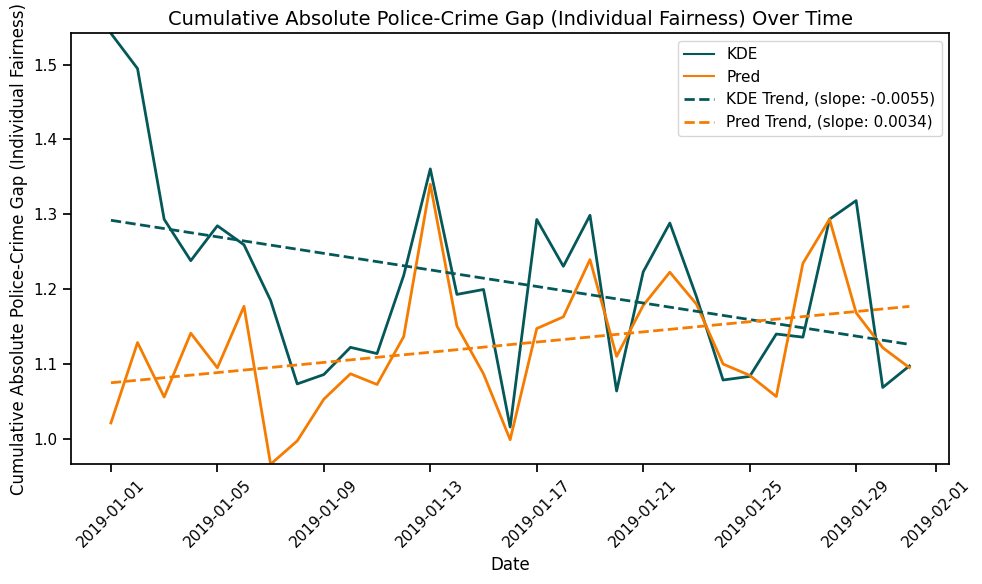

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


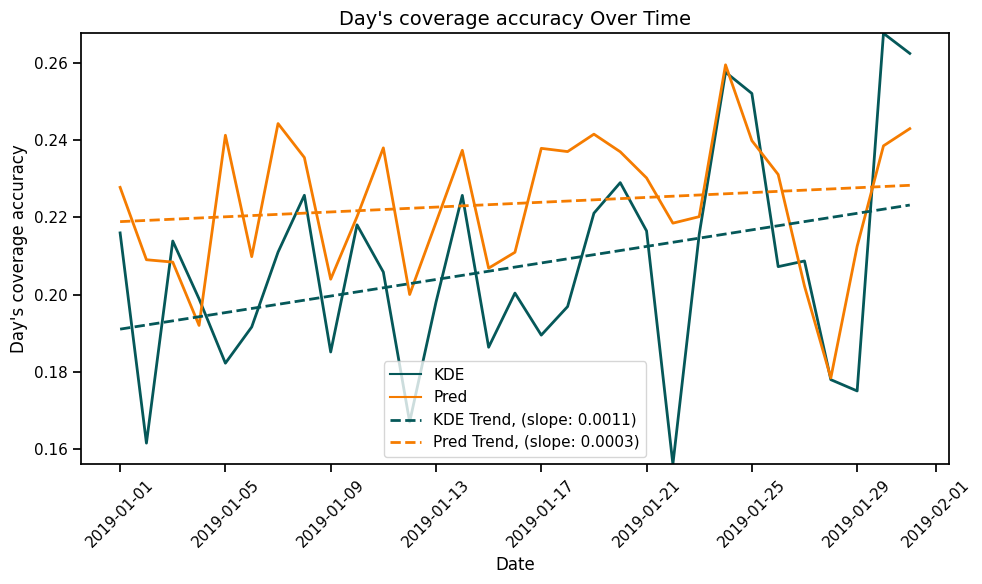

In [27]:
plot_coverageAccuracy_and_PoliceCrimeGap(pMethod="Daily", pRep= 0.4, pNum= 40, cType="TOTAL", based_on="Cumulative")


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


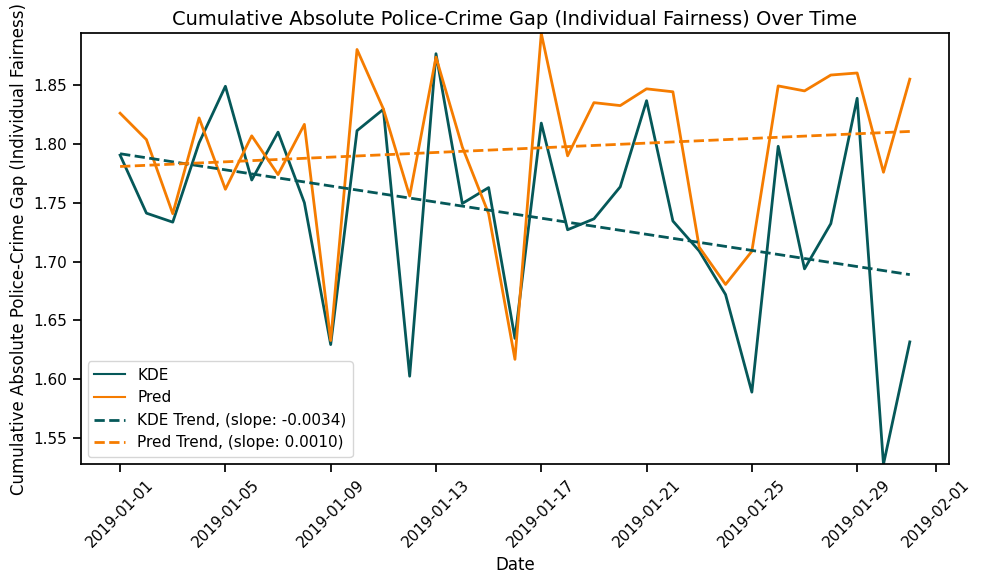

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


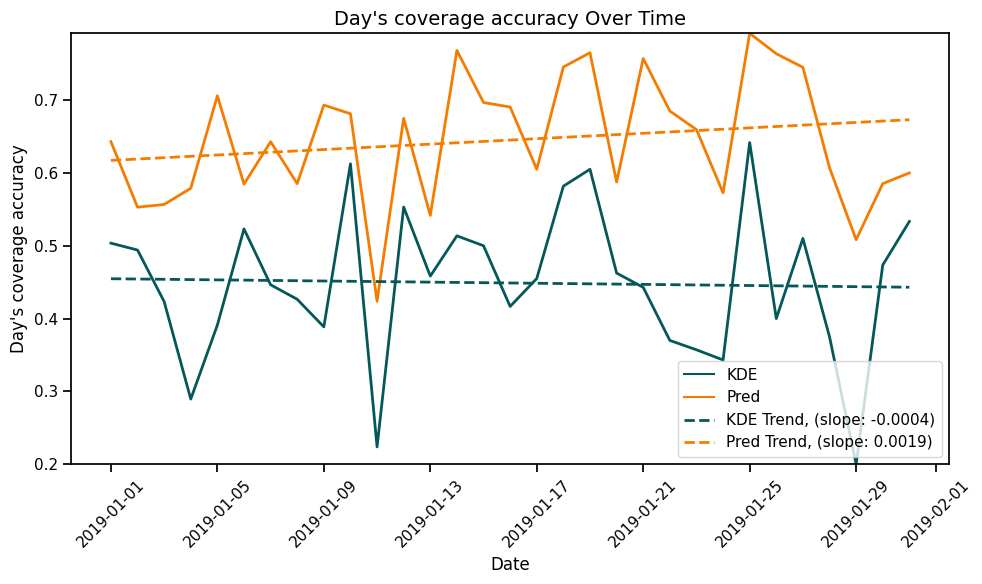

In [28]:
plot_coverageAccuracy_and_PoliceCrimeGap(pMethod="Daily", pRep= 0.4, pNum= 400, cType="BURGLARY", based_on="Cumulative")


<font color='red'>The questions are being answered based on Daily prediction method.</font>

### Questions this plot answers:

#### Aim 1: Fairness and Accuracy Comparison
**1. How does KDE compare to PredPol in terms of fairness and accuracy across scenarios?**

PredPol seems to have higher daily coverage accuracy across scenarios. Cumulative absolute Police-Crime gap, on the other hand, is not that easy to interpret. Both algorithms are performing very closely in terms of the Police-Crime gap. It seems when all crime records are used, KDE has a little bit higher Gap, while for Burglary it is different. 

What was at first surprising to observe in this diagram was that KDE has a negative slope of trendline for police/crime gap in most cases. Does it mean it gets fairer (higher individual fairness) as time passes? In our previous plots we demonstrated how KDE has a higher positive slope of trendline when it comes to standard deviation of police numbers across the neighborhoods over the simulation days. That positive slope indicated less uniformity; meaning officers were being concentrated in some neighborhoods more than others. How is it that this concentration is going towards assigning officers more proportionatly to crimes? The reason is that on a daily basis, a lot of the neighborhoods in Baltimore have no crime recorded. Therefor when officers are concentrated in some neighborhoods, other neighborhoods are left with no survilliance which matches their crime records on most of the days. Note that this zero crime records is probably the result of already biased system caused by low surviliance in those neighborhoods. Even using the biased real-world crime dataset as supposed true distribution, this concentration may start to match the crime proportion better at first but in longer simulations the gap could rise. 

Another thing to note is that for KDE it could take some days to find the hotspots correctly because it only looks at short term crime history while PredPol is assigning scores based on both short term and long term effect of crimes, so PredPol starts out with better risk score determination. Therefore in some scenarios, KDE starts with much higher gaps compared to PredPol. Although on later days the police/crime gaps of the algorithms are becoming more alike, we see a falling trend for KDE, while PredPol has a rising trend. On longer simulation runs the effect of those first few days of KDE on slope of its trendline will subside and we could see the true trend better. 


**2. Are more accurate systems necessarily fairer?**

In the case of using **Burglaries** (especialy, 400 officers, 0.4 pReport), PredPol was less fair (higher cumulative absolute Police-Crime gap) while being noticeably more accurate on a **Daily** basis. This could also be surprising because with this specific metric as a fairness metric we imagine with higher gap between police-share and crime-share the system should detect less crime. how is it that in this scenario, for PredPol, we are seeing a rising trend for accuracy while police-crime proportionality is decreasing? I believe the explenation for this lies in the detection logic. As we explained before determining if a crime gets detected is rhrough a coin toss (Noisy-OR) with higher probability of detection if number of police in that neighborhood is higher. So imagine a neighborhood containing higher shares of crime, there's a certain number of officers more than which almost all crimes in that neighborhood will go detected. Utill the algorithm gets biased enogh to assign close to that many officers, we might see a rise in accuracy. however when the algorithm starts giving more than that number of police to that neighborhood, detection in that neighborhood is not rising any more while detection in other neighborhoods is falling. Again, maybe this simulation needs to run longer to get to that point.</br>

Imagine we have two neighborhoods that are maintaining a zero crime record status in a period in the simulation, and every once in a while they are getting one lone officer, the algorithm's fairness here lies in assigning the same number of officers to these neighborhoods in that period. Therefore, **these algorithms should be analyzed over longer periods as well**. Many neighborhoods have zero daily crime records in Baltimore. In order to have a more logically meaningful analysis, we are going to look at weekly values of these metrics in later plots as well.

## Answering Further Questions on Daily Individual Fairness


In [29]:
base_slice= master_df[master_df["prediction_method"]=="Daily"].copy()
scen_cols = ["crime_type","number_of_police","pReport","prediction_method"]

daily_indFairGap_df= base_slice.groupby(scen_cols+["Date", "Algorithm"]).agg(
    
    day_coverage_accuracy=("TotalDetectedOfDay", lambda x: x.iloc[0] / base_slice.loc[x.index[0], "TotalCrimesOfDay"]),
    Average_abs_policeCrime_gap=("policeCrime_gap", lambda x: x.abs().mean()),
    Cumulative_abs_policeCrime_gap=("policeCrime_gap", lambda x: x.abs().sum()),
    
)
summary_indFairGap=[]
for i, g in daily_indFairGap_df.groupby(scen_cols +["Algorithm"]):
    x = np.arange(len(g))
    acc_slope, acc_intercept,*_= linregress(x, g["day_coverage_accuracy"])
    fair_slope, fair_intercept, *_= linregress(x, g["Cumulative_abs_policeCrime_gap"])
    
    summary_indFairGap.append(
        {
            **dict(zip(scen_cols +["Algorithm"], i)),
            "acc_slope":acc_slope,
            "fairnessGap_slope":fair_slope,
            "acc_trend": "Improving" if acc_slope > 0 else "Worsening",
            "fair_trend": "Improving" if fair_slope <0 else "Worsening",
            "avg_coverage_acc": g["day_coverage_accuracy"].mean(),
            "avg_CumAbsPoliceCrimeGap": g["Cumulative_abs_policeCrime_gap"].mean()
        }
    )  
summary_indFairGap_df = pd.DataFrame(summary_indFairGap) 

compare_alg=[]
for vals, group in summary_indFairGap_df.groupby(scen_cols):
    kde = group[group["Algorithm"] == "KDE"].iloc[0]
    pred = group[group["Algorithm"] == "Pred"].iloc[0]

    compare_alg.append({
        **dict(zip(scen_cols, vals)),
        
        "Fairer_Algorithm": "KDE" if kde["avg_CumAbsPoliceCrimeGap"] < pred["avg_CumAbsPoliceCrimeGap"] else "Pred",
        
        "More_Accurate_Algorithm": "KDE" if kde["avg_coverage_acc"] > pred["avg_coverage_acc"] else "Pred",

        "KDE_Ind_Fairness_Trend": kde["fair_trend"],
        "Pred_Ind_Fairness_Trend": pred["fair_trend"],
        "Faster_Ind_Fairness_Trend": "KDE" if abs(kde["fairnessGap_slope"]) > abs(pred["fairnessGap_slope"]) else "Pred",

        "KDE_Accuracy_Trend": kde["acc_trend"],
        "Pred_Accuracy_Trend": pred["acc_trend"],
        "Faster_Accuracy_Trend": "KDE" if abs(kde["acc_slope"]) > abs(pred["acc_slope"]) else "Pred",
        
        "avg_Ind_Fairness_diff": pred["avg_CumAbsPoliceCrimeGap"] - kde["avg_CumAbsPoliceCrimeGap"],
        "avg_accuracy_diff": pred["avg_coverage_acc"] - kde["avg_coverage_acc"],
        
        "KDE_avg_CumAbsPoliceCrimeGap":kde["avg_CumAbsPoliceCrimeGap"],
        "Pred_avg_CumAbsPoliceCrimeGap":pred["avg_CumAbsPoliceCrimeGap"],
        
        "KDE_avg_coverage_acc":kde["avg_coverage_acc"],
        "Pred_avg_coverage_acc":pred["avg_coverage_acc"]


    })

compare_alg_df= pd.DataFrame(compare_alg)
display(compare_alg_df)


,crime_type,number_of_police,pReport,prediction_method,Fairer_Algorithm,More_Accurate_Algorithm,KDE_Ind_Fairness_Trend,Pred_Ind_Fairness_Trend,Faster_Ind_Fairness_Trend,KDE_Accuracy_Trend,Pred_Accuracy_Trend,Faster_Accuracy_Trend,avg_Ind_Fairness_diff,avg_accuracy_diff,KDE_avg_CumAbsPoliceCrimeGap,Pred_avg_CumAbsPoliceCrimeGap,KDE_avg_coverage_acc,Pred_avg_coverage_acc
0,BURGLARY,40,0.0,Daily,KDE,Pred,Improving,Worsening,KDE,Improving,Improving,KDE,0.038453,0.007203,1.758967,1.797419,0.220627,0.227830
1,BURGLARY,40,0.4,Daily,KDE,Pred,Improving,Worsening,KDE,Improving,Improving,KDE,0.036847,0.002060,1.752508,1.789355,0.232403,0.234463
2,BURGLARY,400,0.0,Daily,KDE,Pred,Improving,Worsening,KDE,Worsening,Improving,KDE,0.057402,0.186676,1.739437,1.796839,0.462165,0.648841
3,BURGLARY,400,0.4,Daily,KDE,Pred,Improving,Worsening,KDE,Worsening,Improving,Pred,0.055512,0.196236,1.740318,1.795831,0.448883,0.645120
4,TOTAL,40,0.0,Daily,Pred,Pred,Improving,Worsening,KDE,Improving,Improving,KDE,-0.101435,0.017361,1.219571,1.118135,0.208171,0.225532
5,TOTAL,40,0.4,Daily,Pred,Pred,Improving,Worsening,KDE,Improving,Improving,KDE,-0.083210,0.016494,1.208977,1.125767,0.207108,0.223602
6,TOTAL,400,0.0,Daily,KDE,Pred,Worsening,Worsening,Pred,Worsening,Worsening,KDE,0.002733,0.084331,1.098484,1.101217,0.523991,0.608323
7,TOTAL,400,0.4,Daily,Pred,Pred,Worsening,Worsening,Pred,Worsening,Improving,KDE,-0.000131,0.092225,1.100330,1.100199,0.522799,0.615024


In [30]:
print("\nDaily Accuracy and Individual Fairness Results:\n")
pred_fairer=compare_alg_df["Fairer_Algorithm"]=="Pred"
print(f"Out of {len(compare_alg_df)} scenarios, { 100 * pred_fairer.mean()}% of scenarios have PredPol as fairer Algorithm.")
pred_accurate=compare_alg_df["More_Accurate_Algorithm"]=="Pred"
print(f"Out of {len(compare_alg_df)} scenarios, { 100 * pred_accurate.mean()}% of scenarios have PredPol as more accurate Algorithm.")

KDE_changes_faster= compare_alg_df["Faster_Ind_Fairness_Trend"]=="KDE"
print(f"Out of {len(compare_alg_df)} scenarios, { 100 * KDE_changes_faster.mean()}% of scenarios have KDE as the faster changing Algorithm in terms of police_crime-gap over days.")

KDE_Fairness_worsening= compare_alg_df["KDE_Ind_Fairness_Trend"]=="Worsening"
print(f"Out of {len(compare_alg_df)} scenarios, { 100 * KDE_Fairness_worsening.mean()}% show that KDE's becoming less fair.")
     
Pred_Fairness_worsening= compare_alg_df["Pred_Ind_Fairness_Trend"]=="Worsening"
print(f"Out of {len(compare_alg_df)} scenarios, { 100 * Pred_Fairness_worsening.mean()}% show thatPredPol's becoming less fair.")

KDE_Acc_worsening= compare_alg_df["KDE_Accuracy_Trend"]=="Worsening"
print(f"Out of {len(compare_alg_df)} scenarios, { 100 * KDE_Acc_worsening.mean()}% show that KDE's becoming less accurate.")
  
    
Pred_Acc_worsening= compare_alg_df["Pred_Accuracy_Trend"]=="Worsening"
print(f"Out of {len(compare_alg_df)} scenarios, { 100 * Pred_Acc_worsening.mean()}% show that PredPol's becoming less accurate.")


kde_fair_margin = compare_alg_df[compare_alg_df["Fairer_Algorithm"] == "KDE"]["avg_Ind_Fairness_diff"].mean()
pred_fair_margin = compare_alg_df[compare_alg_df["Fairer_Algorithm"] == "Pred"]["avg_accuracy_diff"].mean()

print(f"\nAvg fairness margin when KDE is fairer: {kde_fair_margin:.3f}")
print(f"Avg fairness margin when Pred is fairer: {pred_fair_margin:.3f}")



Daily Accuracy and Individual Fairness Results:

Out of 8 scenarios, 37.5% of scenarios have PredPol as fairer Algorithm.
Out of 8 scenarios, 100.0% of scenarios have PredPol as more accurate Algorithm.
Out of 8 scenarios, 75.0% of scenarios have KDE as the faster changing Algorithm in terms of police_crime-gap over days.
Out of 8 scenarios, 25.0% show that KDE's becoming less fair.
Out of 8 scenarios, 100.0% show thatPredPol's becoming less fair.
Out of 8 scenarios, 50.0% show that KDE's becoming less accurate.
Out of 8 scenarios, 12.5% show that PredPol's becoming less accurate.

Avg fairness margin when KDE is fairer: 0.038
Avg fairness margin when Pred is fairer: 0.042



---
## Creating Weekly Reports Dataframes

Here we are using master_df to create weekly reports, including the values for each neighborhoods' Police-Crime gap in a week in a scenario. Two dataframes are created here:
1. weekly_Nei_df: This dataframe has Neighborhood + scnenario + weekLabel as index. It contains weekly values for number of officers, number of crimes, number of crimes detected, police share, crime share, Police-Crime gap, etc.
2. weekly_df: This dataframe has scenario + weeklabel as index. It contains week's cumulative absolute Police-Crime gap of all neighborhoods, average absolute Police-Crime gap, etc.

In [31]:
base_slice = master_df[master_df["prediction_method"]=="Daily"].copy()
scen =scenario_cols.copy()

base_slice["Week"] = base_slice["Date"].dt.to_period("W").apply(lambda r: r.start_time)
week_order = {week: f"Week {i+1}" for i, week in enumerate(sorted(base_slice["Week"].unique()))}
base_slice["WeekLabel"] = base_slice["Week"].map(week_order)

group_cols = ["WeekLabel","Week"]+ scen
weekly_Nei_df = base_slice.groupby(group_cols+["Neighborhood","IsBlack","IsWhite"]).agg(
    weekly_policeNum=("PoliceNum", "sum"),
    weekly_crimesNum=("CrimesNum", "sum"),
    weekly_DetectedNum=("DetectedNum", "sum"),
    #weekly_total_crime=("CrimesNum", "sum")
).reset_index()

weekly_df = weekly_Nei_df.groupby(group_cols).agg(
    weekly_total_police=("weekly_policeNum", "sum"),
    weekly_total_crime=("weekly_crimesNum", "sum"),
    weekly_total_Detected=("weekly_DetectedNum", "sum"),
).reset_index()

weekly_Nei_df = weekly_Nei_df.merge(weekly_df, on=group_cols, how="left")
weekly_Nei_df["weekly_detected_perc"]= weekly_Nei_df["weekly_DetectedNum"]/weekly_Nei_df["weekly_crimesNum"]
weekly_Nei_df["weekly_crime_share"]= weekly_Nei_df["weekly_crimesNum"]/weekly_Nei_df["weekly_total_crime"]
weekly_Nei_df["weekly_police_share"]= weekly_Nei_df["weekly_policeNum"]/weekly_Nei_df["weekly_total_police"]
weekly_Nei_df["weekly_policeCrime_gap"]=weekly_Nei_df["weekly_police_share"] - weekly_Nei_df["weekly_crime_share"]
weekly_Nei_df["weekly_abs_policeCrime_gap"]=weekly_Nei_df["weekly_policeCrime_gap"].abs()

weekly_df["coverage_accuracy"] = (
    (weekly_df["weekly_total_Detected"] + 1) / (weekly_df["weekly_total_crime"] + 1)
)

a= weekly_Nei_df.groupby(group_cols).agg(
    Average_abs_policeCrime_gap = ("weekly_abs_policeCrime_gap","mean"),
    Cumulative_abs_policeCrime_gap = ("weekly_abs_policeCrime_gap", "sum")
    ).reset_index()

weekly_df= weekly_df.merge(a, on=group_cols, how="left")
display(weekly_df)
display(weekly_Nei_df)

,WeekLabel,Week,prediction_method,crime_type,number_of_police,pReport,Algorithm,weekly_total_police,weekly_total_crime,weekly_total_Detected,coverage_accuracy,Average_abs_policeCrime_gap,Cumulative_abs_policeCrime_gap
0,Week 1,2018-12-31,Daily,BURGLARY,40,0.0,KDE,227.45,95.0,16.90,0.186458,0.004973,1.273131
1,Week 1,2018-12-31,Daily,BURGLARY,40,0.0,Pred,240.00,95.0,19.45,0.213021,0.004765,1.219912
2,Week 1,2018-12-31,Daily,BURGLARY,40,0.4,KDE,228.60,95.0,17.95,0.197396,0.004939,1.264318
3,Week 1,2018-12-31,Daily,BURGLARY,40,0.4,Pred,240.00,95.0,19.95,0.218229,0.004703,1.204079
4,Week 1,2018-12-31,Daily,BURGLARY,400,0.0,KDE,2255.55,95.0,41.80,0.445833,0.004722,1.208710
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,Week 5,2019-01-28,Daily,TOTAL,40,0.4,Pred,160.00,415.0,89.95,0.218630,0.002427,0.621310
76,Week 5,2019-01-28,Daily,TOTAL,400,0.0,KDE,1567.55,415.0,189.40,0.457692,0.002859,0.731822
77,Week 5,2019-01-28,Daily,TOTAL,400,0.0,Pred,1600.00,415.0,244.95,0.591226,0.002400,0.614380
78,Week 5,2019-01-28,Daily,TOTAL,400,0.4,KDE,1567.95,415.0,192.55,0.465264,0.002871,0.734855


,WeekLabel,Week,prediction_method,crime_type,number_of_police,pReport,Algorithm,Neighborhood,IsBlack,IsWhite,...,weekly_crimesNum,weekly_DetectedNum,weekly_total_police,weekly_total_crime,weekly_total_Detected,weekly_detected_perc,weekly_crime_share,weekly_police_share,weekly_policeCrime_gap,weekly_abs_policeCrime_gap
0,Week 1,2018-12-31,Daily,BURGLARY,40,0.0,KDE,ABELL,False,True,...,0.0,0.00,227.45,95.0,16.9,NaN,0.000000,0.000000,0.000000,0.000000
1,Week 1,2018-12-31,Daily,BURGLARY,40,0.0,KDE,ALLENDALE,True,False,...,0.0,0.00,227.45,95.0,16.9,NaN,0.000000,0.001099,0.001099,0.001099
2,Week 1,2018-12-31,Daily,BURGLARY,40,0.0,KDE,ARCADIA,False,True,...,0.0,0.00,227.45,95.0,16.9,NaN,0.000000,0.000000,0.000000,0.000000
3,Week 1,2018-12-31,Daily,BURGLARY,40,0.0,KDE,ARLINGTON,True,False,...,0.0,0.00,227.45,95.0,16.9,NaN,0.000000,0.000000,0.000000,0.000000
4,Week 1,2018-12-31,Daily,BURGLARY,40,0.0,KDE,ARMISTEAD GARDENS,False,True,...,0.0,0.00,227.45,95.0,16.9,NaN,0.000000,0.006375,0.006375,0.006375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20475,Week 5,2019-01-28,Daily,TOTAL,400,0.4,Pred,WRENLANE,True,False,...,1.0,0.15,1600.00,415.0,248.6,0.150,0.002410,0.000594,-0.001816,0.001816
20476,Week 5,2019-01-28,Daily,TOTAL,400,0.4,Pred,WYMAN PARK,False,True,...,1.0,0.30,1600.00,415.0,248.6,0.300,0.002410,0.001531,-0.000878,0.000878
20477,Week 5,2019-01-28,Daily,TOTAL,400,0.4,Pred,WYNDHURST,False,True,...,0.0,0.00,1600.00,415.0,248.6,NaN,0.000000,0.000250,0.000250,0.000250
20478,Week 5,2019-01-28,Daily,TOTAL,400,0.4,Pred,YALE HEIGHTS,True,False,...,2.0,0.95,1600.00,415.0,248.6,0.475,0.004819,0.002750,-0.002069,0.002069


## Weekly Coverage Accuracy and Police-Crime Gap (line plots)
This time we try the ploting the same metrics of Coverage accuracy and cumulative absolute Police-Crime gap but over a weeks period.

In [32]:
def plot_coverageAccuracy_and_policeCrimeGap_weekly(pRep= 0.4, pNum= 40, cType="TOTAL", based_on="Cumulative"):
    
    base_slice = weekly_df[
        (weekly_df["crime_type"] == cType) &
        (weekly_df["number_of_police"] == pNum) &
        (weekly_df["pReport"]==pRep)
    ].copy()

    fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    sns.lineplot(
        data=base_slice,
        x="WeekLabel",
        y=f"{based_on}_abs_policeCrime_gap",
        hue="Algorithm",
        ax=axs[0],
        palette=palette_dict,
        errorbar = None
    )
    axs[0].set_title(f"Weekly {based_on} Absolute Police-Crime Gap")
    axs[0].set_ylabel(f"{based_on} Abs Police-Crime Gap")

    sns.lineplot(
        data=base_slice,
        x="WeekLabel",
        y="coverage_accuracy",
        hue="Algorithm",
        ax=axs[1],
        palette=palette_dict,
        errorbar = None
    )
    axs[1].set_title("Weekly Coverage Accuracy (Detected / Crimes)")
    axs[1].set_ylabel("Coverage Accuracy")

    plt.tight_layout()
    
    save_title = f'AccuracyVs{based_on}FairnessOverTime_{pRep}_{cType}_{pNum}'
    plt.savefig(f'{RRF}/{save_title}.png')
    plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
    plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


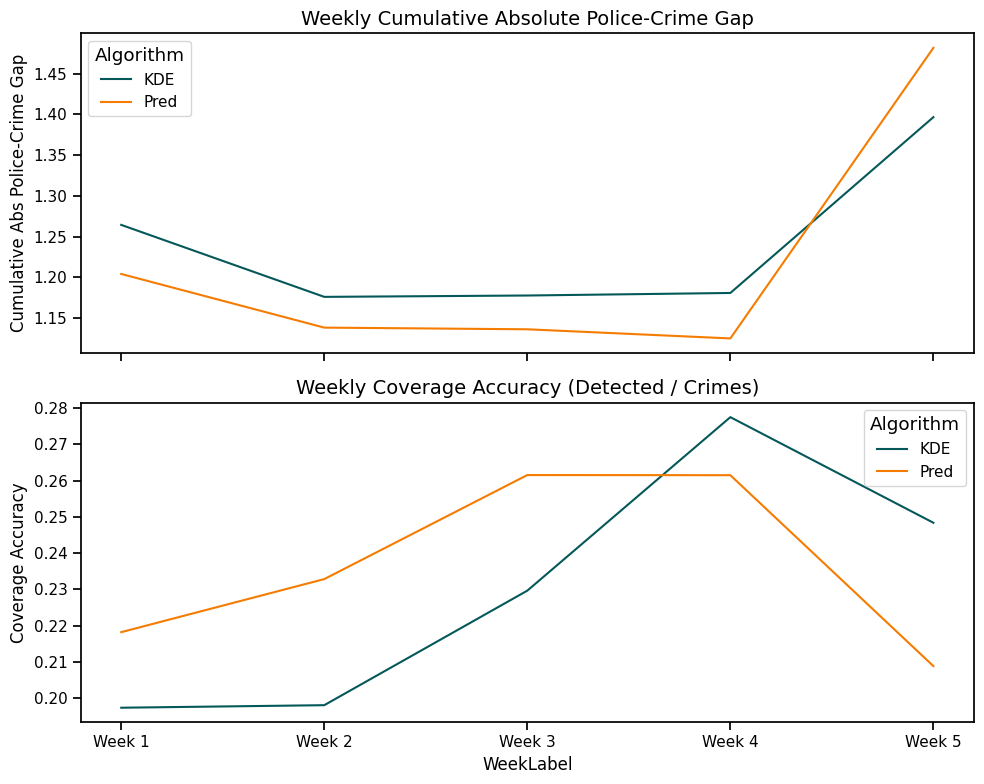

In [33]:
plot_coverageAccuracy_and_policeCrimeGap_weekly(pRep= 0.4, pNum= 40, cType="BURGLARY", based_on="Cumulative")



### Questions this plot answers:
#### Aim 1: Fairness and Accuracy Comparison
**1. How does KDE compare to PredPol in terms of fairness and accuracy across scenarios?**

For weekly analysis, the accuracy of PredPol is higher in almost every scenario. It is also mostly fairer than KDE, but there are some scenarios in which KDE becomes fairer. By "fairer," we mean a lower cumulative Police-Crime gap.

**2. Are more accurate systems necessarily fairer?**

In most of these diagrams, the more accurate system, PredPol, happens to be the fairer algorithm, but there are some cases in which this does not hold true based on these plots.

#### Aim 2: Temporal Feedback Loop Effects
**1. Does bias amplify over time?** 

In these weekly analysis, for both algorithms, the Police-Crime gap lowers at first but then takes a turn toward a higher gap with a steeper slope.

**2. Do different systems respond differently to feedback loops?** 

Although both algorithms seem to follow the same general trend, KDE has higher slopes in its trends most of the time, indicating a less stable response to the feedback effect.

#### Aim 3: Impact of Crime Type
**1. How does the choice of crime type (e.g., burglary vs total crimes) affect bias?** 

Most of the cases that KDE becomes fairer, the crime records used is Burglaries, while when using Total crime records, PredPol generally stays fairer and more accurate. When using all crime records Police-Crime gap for both algorithms is less compared to when Burglary records are used.

#### Aim 4: Is Bias Data-Driven or Model-Driven?
**1. What happens when the same data is used in different models?**

As it was explained PredPol and KDE had different accuracy and fairness levels.

**2. What happens when the same model is fed different data?**

As it was explained different data changes the fairness levels and accuracy.



---

## Average Absolute Police-Crime Gap Vs.  Coverage Accuracy (scatter plot)

In this plot, each data point represents a week in the simulation. More recent days have higher opacity, while earlier days in the simulation are more transparent.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


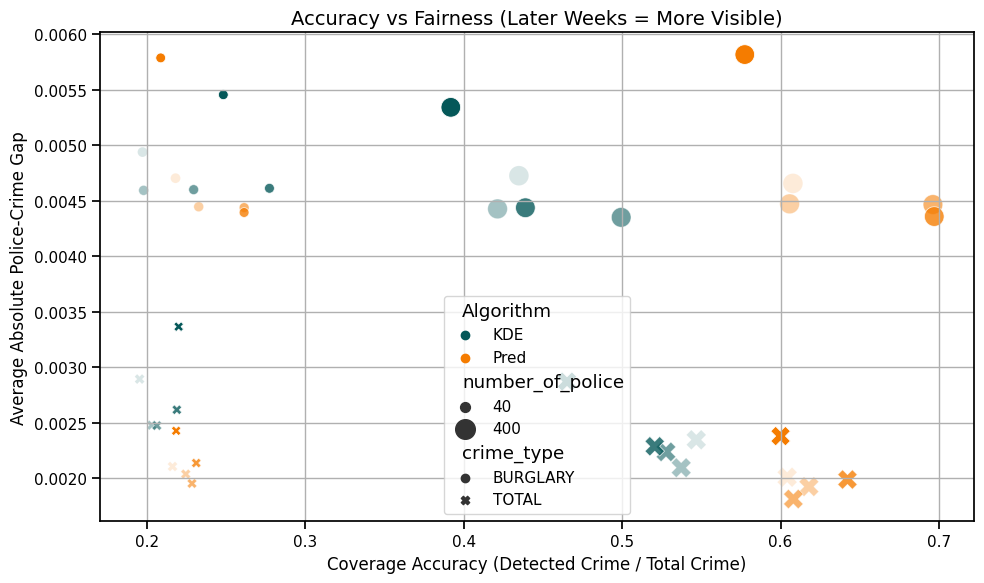

In [34]:
subset = weekly_df[
    (weekly_df["pReport"]==0.4)
].copy()
# subset = weekly_df[
#     (weekly_df["pReport"].isin([0.1, 0.9]))&
#     (weekly_df["number_of_police"]==400)
# ].copy()
subset["alpha"] = 0.15 + 0.85 * (subset["Week"] - subset["Week"].min()) / (subset["Week"].max() - subset["Week"].min())

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=subset,
    x="coverage_accuracy",
    y="Average_abs_policeCrime_gap",
    hue="Algorithm",
    style="crime_type",
    size="number_of_police", #"pReport",
    sizes=(50, 200),
    palette=palette_dict,
    alpha=subset["alpha"]
)

plt.title("Accuracy vs Fairness (Later Weeks = More Visible)")
plt.xlabel("Coverage Accuracy (Detected Crime / Total Crime)")
plt.ylabel("Average Absolute Police-Crime Gap")
plt.grid(True)

plt.tight_layout()
    
save_title = f'AccuracyVsAverageAbsFairnessOverTime_0.4'
plt.savefig(f'{RRF}/{save_title}.png')
plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
plt.show()


### Questions this plot answers:
#### Aim 1: Fairness and Accuracy Comparison
**1. How does KDE compare to PredPol in terms of fairness and accuracy across scenarios?** 

Looking at these weekly values appearing on the scatter plot, KDE points are obviously at lower values relative to comparative PredPol points when it comes to accuracy. For fairness, however, it is a bit less clear.

**2. Are more accurate systems necessarily fairer?**

On this diagram It is clearly shown that accurate systems are emerging all over the average Police-Crime gap spectrum.

#### Aim 2: Temporal Feedback Loop Effects

**1. Does bias amplify over time?**

It is evident that More opaque points stand generally higher than the others, indicating the average absolute Police-Crime gap grows over time.  

#### Aim 3: Impact of Crime Type

**1. How does the choice of crime type (e.g., burglary vs total crimes) affect bias?**

Using Burglary records the Police-Crime gap is higher for both algorithms. but we can't conclude about the data's effect on accuracy levels with confidence based on this diagram.


Note: Police Number is not affecting fairness but does result in higher coverage accuracy, as expected.

---

## Further Weekly Analysis
To make it more clear Let's answer more questions. How many times is which model fairer or more accurate? What is the average difference when KDE is fairer and what is it when PredPol is fairer?

We are answering these questions using a new dataframe, called **weekly_scenario_summary** containing average difference between coverage accuracy of the two algorithm, **avg_accuracy_diff**, and average difference between the cumulative Police-Crime gap of the two, **avg_policeCrime_diff**, for each scenario.


In [35]:
pivot_df = weekly_df.pivot_table(
    index=["WeekLabel", "crime_type", "number_of_police", "pReport"],
    columns="Algorithm",
    values=["Cumulative_abs_policeCrime_gap", "coverage_accuracy"]
).reset_index()

pivot_df.columns = ['_'.join(col).strip('_') for col in pivot_df.columns.values]

pivot_df["policeCrime_gap_diff"] = pivot_df["Cumulative_abs_policeCrime_gap_Pred"] - pivot_df["Cumulative_abs_policeCrime_gap_KDE"]
pivot_df["accuracy_diff"] = pivot_df["coverage_accuracy_Pred"] - pivot_df["coverage_accuracy_KDE"]
display(pivot_df)

,WeekLabel,crime_type,number_of_police,pReport,Cumulative_abs_policeCrime_gap_KDE,Cumulative_abs_policeCrime_gap_Pred,coverage_accuracy_KDE,coverage_accuracy_Pred,policeCrime_gap_diff,accuracy_diff
0,Week 1,BURGLARY,40,0.0,1.273131,1.219912,0.186458,0.213021,-0.053219,0.026563
1,Week 1,BURGLARY,40,0.4,1.264318,1.204079,0.197396,0.218229,-0.060239,0.020833
2,Week 1,BURGLARY,400,0.0,1.208710,1.187257,0.445833,0.614583,-0.021454,0.168750
3,Week 1,BURGLARY,400,0.4,1.209786,1.192007,0.434896,0.607812,-0.017779,0.172917
4,Week 1,TOTAL,40,0.0,0.744143,0.545960,0.200132,0.220569,-0.198182,0.020437
5,Week 1,TOTAL,40,0.4,0.740607,0.538935,0.195569,0.216336,-0.201672,0.020767
6,Week 1,TOTAL,400,0.0,0.603967,0.517109,0.546429,0.602646,-0.086858,0.056217
7,Week 1,TOTAL,400,0.4,0.600566,0.514241,0.546825,0.604167,-0.086325,0.057341
8,Week 2,BURGLARY,40,0.0,1.184709,1.140687,0.192381,0.223810,-0.044022,0.031429
9,Week 2,BURGLARY,40,0.4,1.175972,1.138242,0.198095,0.232857,-0.037730,0.034762


In [36]:
weekly_scenario_summary = pivot_df.groupby([
    "crime_type", "number_of_police", "pReport"
]).agg(
    avg_policeCrime_diff=("policeCrime_gap_diff", "mean"),
    avg_accuracy_diff=("accuracy_diff", "mean"), 
    pred_avg_coverage_acc= ("coverage_accuracy_Pred","mean"),
    kde_avg_coverage_acc= ("coverage_accuracy_KDE","mean"),
    pred_avg_IndFGap_weeklyPers = ("Cumulative_abs_policeCrime_gap_Pred","mean"),
    kde_avg_IndFGap_weeklyPers = ("Cumulative_abs_policeCrime_gap_KDE","mean")
).reset_index()
display(weekly_scenario_summary)

,crime_type,number_of_police,pReport,avg_policeCrime_diff,avg_accuracy_diff,pred_avg_coverage_acc,kde_avg_coverage_acc,pred_avg_IndFGap_weeklyPers,kde_avg_IndFGap_weeklyPers
0,BURGLARY,40,0.0,-0.018687,0.014738,0.231401,0.216663,1.234432,1.253119
1,BURGLARY,40,0.4,-0.022034,0.006389,0.236599,0.230210,1.217013,1.239048
2,BURGLARY,400,0.0,0.034311,0.190854,0.641171,0.450316,1.220852,1.186541
3,BURGLARY,400,0.4,0.024976,0.199478,0.636820,0.437342,1.217011,1.192036
4,TOTAL,40,0.0,-0.180052,0.016746,0.226174,0.209429,0.541482,0.721535
5,TOTAL,40,0.4,-0.162213,0.015010,0.223911,0.208901,0.545700,0.707913
6,TOTAL,400,0.0,-0.086037,0.087464,0.607589,0.520125,0.520202,0.606239
7,TOTAL,400,0.4,-0.088259,0.094929,0.614477,0.519548,0.517737,0.605996


In [37]:
print("\n Weekly individual fairness results. \n")
weekly_scenario_summary["fairer_algo"] = weekly_scenario_summary["avg_policeCrime_diff"].apply(
    lambda x: "KDE" if x > 0 else "Pred" if x < 0 else "Tie"
)

weekly_scenario_summary["more_accurate_algo"] = weekly_scenario_summary["avg_accuracy_diff"].apply(
    lambda x: "KDE" if x < 0 else "Pred" if x > 0 else "Tie"
)
print("Number of scenarios each algorithm becomes fairest?")
print(weekly_scenario_summary["fairer_algo"].value_counts())

print("\nHow many scenarios where Pred is more accurate?")
print(weekly_scenario_summary["more_accurate_algo"].value_counts())

kde_fair_margin = weekly_scenario_summary[weekly_scenario_summary["fairer_algo"] == "KDE"]["avg_policeCrime_diff"].mean()
pred_fair_margin = weekly_scenario_summary[weekly_scenario_summary["fairer_algo"] == "Pred"]["avg_policeCrime_diff"].mean()

print(f"\nAvg fairness margin when KDE is fairer: {kde_fair_margin:.3f}")
print(f"Avg fairness margin when Pred is fairer: {pred_fair_margin:.3f}")



 Weekly individual fairness results. 

Number of scenarios each algorithm becomes fairest?
Pred    6
KDE     2
Name: fairer_algo, dtype: int64

How many scenarios where Pred is more accurate?
Pred    8
Name: more_accurate_algo, dtype: int64

Avg fairness margin when KDE is fairer: 0.030
Avg fairness margin when Pred is fairer: -0.093


---
## Average Fairness Diff vs. Average Accuracy Diff (scatter plot)

Looking more closely at a scatter plot of average fairness difference versus Average accuracy difference, each data point represents a scenario. This will help us visualize how PredPol and KDE are behaving in general across scenarios. To calculate Average Fairness Diff and Average Accuracy Diff, weekly differences of values related to these metrics for PredPol and KDE are calculated in each scenario. Then these differences are averaged over the weeks of simulation for each scenario.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


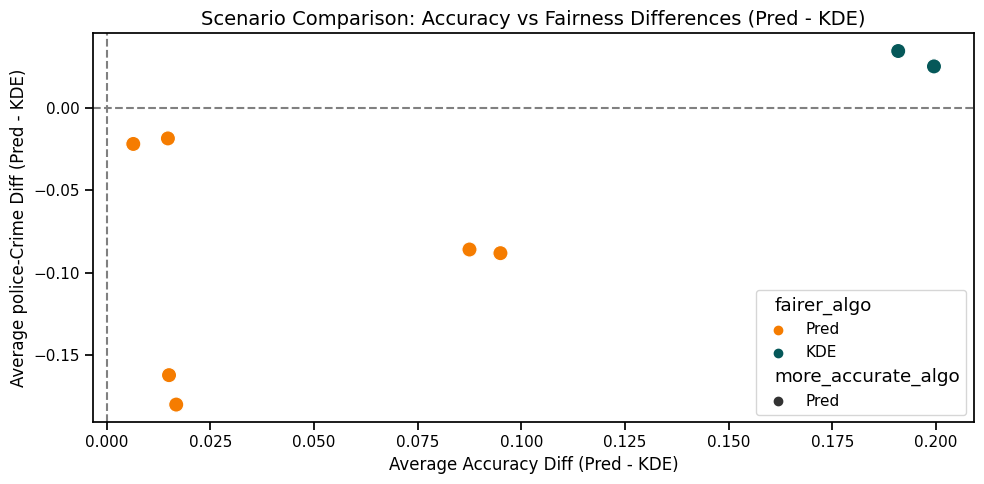

In [38]:
plt.figure(figsize=(10, 5)) 
sns.scatterplot(
    data=weekly_scenario_summary,
    x="avg_accuracy_diff",
    y="avg_policeCrime_diff",
    hue="fairer_algo",
    palette = palette_dict,
    s=120,
    style="more_accurate_algo"
)
plt.axhline(0, linestyle="--", color="gray")
plt.axvline(0, linestyle="--", color="gray")
plt.title("Scenario Comparison: Accuracy vs Fairness Differences (Pred - KDE)")
plt.xlabel("Average Accuracy Diff (Pred - KDE)")
plt.ylabel("Average police-Crime Diff (Pred - KDE)")
# plt.legend(
#     bbox_to_anchor=(1.05, 1),
#     loc='upper left',
#     borderaxespad=0.
# )

plt.tight_layout()
    
save_title = f'AvgAccuracyDiff_Vs_AvgFairnessDiff_All'
plt.savefig(f'{RRF}/{save_title}.png')
plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
plt.show()


### Questions this plot answers:
#### Aim 1: Fairness and Accuracy Comparison
**1. How does KDE compare to PredPol in terms of fairness and accuracy across scenarios?** 

Again, in the weekly analysis here, we see that the average Police-Crime gap difference is mostly negative across scenarios, indicating higher values for the Police-Crime gap of KDE, meaning PredPol is usually fairer, and all but a few data points are showing higher accuracy for PredPol.

**2. Are more accurate systems necessarily fairer?**

PredPol is usually fairer and more accurate, but then those teal circle data points represent scenarios where PredPol was more accurate on average while it was less fair.

---

## Answering Further Questions

In [39]:
kde_fair_df = weekly_scenario_summary[weekly_scenario_summary["fairer_algo"] == "KDE"]
total_kde_fair = len(kde_fair_df)*100/ len(weekly_scenario_summary)

pct_kde_fair_burglary = (kde_fair_df["crime_type"] == "BURGLARY").mean() * 100
pct_kde_fair_400police = (kde_fair_df["number_of_police"] == 400).mean() * 100

print(f"KDE is fairer in {total_kde_fair}% of scenarios.")
print(f"Of those, {pct_kde_fair_burglary:.1f}% involve BURGLARY.")
print(f"Of those, {pct_kde_fair_400police:.1f}% have 400 officers.")


KDE is fairer in 25.0% of scenarios.
Of those, 100.0% involve BURGLARY.
Of those, 100.0% have 400 officers.


## Comparing Model-Behavior Based on Crime-Type

In [40]:
summary_racial_df= summary_racial_df[summary_racial_df["prediction_method"]=="Daily"]
summary_indFairGap_df = summary_indFairGap_df[summary_indFairGap_df["prediction_method"]=="Daily"]

scen_cols = ["crime_type","number_of_police","pReport","Algorithm"]

all_summary_df= summary_indFairGap_df.merge(summary_racial_df[scen_cols+["avg_Abs_Racial_Fgap","avg_Racial_Fgap","racial_fairnessGap_slope"]], on=scen_cols)

all_summary_df.loc[all_summary_df["Algorithm"] == "KDE", "avg_IndFGap_weeklyPers"] = (
    weekly_scenario_summary["kde_avg_IndFGap_weeklyPers"].values
)
all_summary_df.loc[all_summary_df["Algorithm"] == "Pred", "avg_IndFGap_weeklyPers"] = (
    weekly_scenario_summary["pred_avg_IndFGap_weeklyPers"].values
)
 
all_summary_df_pivot =all_summary_df.pivot_table(
    index=["number_of_police","pReport","Algorithm"],
    columns="crime_type"
)
all_summary_df_pivot.columns=["_".join(cols).strip("_") for cols in all_summary_df_pivot.columns.values]

#Non-numeric columns can not pass through the pivot so I'm adding them manually after pivoting
for m in["racial_fairness_trend","race_policeFocus_in_sim","race_policeFocus_direction"]:
    for c in["TOTAL","BURGLARY"]:
        all_summary_df_pivot[f"{m}_{c}"]=list(summary_racial_df[summary_racial_df["crime_type"]==c][m] )
    #     all_summary_df_pivot[f"_{c}"]= list(summary_racial_df[summary_racial_df["crime_type"]==c]["race_policeFocus_direction"]) 


mask = all_summary_df_pivot["avg_Abs_Racial_Fgap_BURGLARY"] < all_summary_df_pivot["avg_Abs_Racial_Fgap_TOTAL"]
# all_summary_df_pivot["Higher_RacialFairness"]= "BURGLARY" if  else "TOTAL"
all_summary_df_pivot.loc[mask,"Higher_RacialFairness"]= "BURGLARY"
all_summary_df_pivot.loc[~(mask),"Higher_RacialFairness"]= "TOTAL"

mask= all_summary_df_pivot["avg_CumAbsPoliceCrimeGap_BURGLARY"] < all_summary_df_pivot["avg_CumAbsPoliceCrimeGap_TOTAL"]
all_summary_df_pivot.loc[mask,"Higher_IndFairness_DailyPers"]= "BURGLARY" 
all_summary_df_pivot.loc[~(mask),"Higher_IndFairness_DailyPers"]= "TOTAL"

mask= all_summary_df_pivot["avg_IndFGap_weeklyPers_BURGLARY"] < all_summary_df_pivot["avg_IndFGap_weeklyPers_TOTAL"]
all_summary_df_pivot.loc[mask,"Higher_IndFairness_WeeklyPers"]= "BURGLARY"
all_summary_df_pivot.loc[~(mask),"Higher_IndFairness_WeeklyPers"]= "TOTAL"

mask= all_summary_df_pivot["avg_coverage_acc_BURGLARY"]>all_summary_df_pivot["avg_coverage_acc_TOTAL"]
all_summary_df_pivot.loc[mask,"Higher_acc_dailyPers"]= "BURGLARY" 
all_summary_df_pivot.loc[~(mask),"Higher_acc_dailyPers"]= "TOTAL"

display(all_summary_df_pivot)


/var/folders/mj/g2_tl79950d3zp7jpg6b_z6r0000gn/T/ipykernel_58811/2311568894.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  all_summary_df_pivot =all_summary_df.pivot_table(


acc_slope_BURGLARY  acc_slope_TOTAL  \
number_of_police pReport Algorithm                                        
40               0.0     KDE                  0.002003         0.000830   
                         Pred                 0.000515         0.000232   
                 0.4     KDE                  0.002901         0.001072   
                         Pred                 0.000182         0.000314   
400              0.0     KDE                 -0.000648        -0.002415   
                         Pred                 0.000477        -0.000089   
                 0.4     KDE                 -0.000388        -0.002261   
                         Pred                 0.001861         0.000615   

                                    avg_Abs_Racial_Fgap_BURGLARY  \
number_of_police pReport Algorithm                                 
40               0.0     KDE                            0.002121   
                         Pred                           0.001758   
                 0.4     KDE                            0.002096   
                         Pred                           0.001852   
400              0.0     KDE                            0.001932   
                         Pred                           0.001790   
                 0.4     KDE                            0.001909   
                         Pred                           0.001811   

                                    avg_Abs_Racial_Fgap_TOTAL  \
number_of_police pReport Algorithm                              
40               0.0     KDE                         0.000853   
                         Pred                        0.000847   
                 0.4     KDE                         0.000745   
                         Pred                        0.000749   
400              0.0     KDE                         0.000809   
                         Pred                        0.000768   
                 0.4     KDE                         0.000757   
                         Pred                        0.000805   

                                    avg_CumAbsPoliceCrimeGap_BURGLARY  \
number_of_police pReport Algorithm                                      
40               0.0     KDE                                 1.758967   
                         Pred                                1.797419   
                 0.4     KDE                                 1.752508   
                         Pred                                1.789355   
400              0.0     KDE                                 1.739437   
                         Pred                                1.796839   
                 0.4     KDE                                 1.740318   
                         Pred                                1.795831   

                                    avg_CumAbsPoliceCrimeGap_TOTAL  \
number_of_police pReport Algorithm                                   
40               0.0     KDE                              1.219571   
                         Pred                             1.118135   
                 0.4     KDE                              1.208977   
                         Pred                             1.125767   
400              0.0     KDE                              1.098484   
                         Pred                             1.101217   
                 0.4     KDE                              1.100330   
                         Pred                             1.100199   

                                    avg_IndFGap_weeklyPers_BURGLARY  \
number_of_police pReport Algorithm                                    
40               0.0     KDE                               1.253119   
                         Pred                              1.234432   
                 0.4     KDE                               1.239048   
                         Pred                              1.217013   
400              0.0     KDE                               1.186541   
                        

In [41]:
c="TOTAL"
x=100 * (all_summary_df_pivot["Higher_IndFairness_DailyPers"]==c).mean()
print(f"In {x}% of scenarios, when using {c} crime-records we get higher individual fairness (Daily perpective).")

x=100 * (all_summary_df_pivot["Higher_IndFairness_WeeklyPers"]==c).mean()
print(f"In {x}% of scenarios, when using {c} crime-records we get higher individual fairness (Weekly perspective).")


x=100 * (all_summary_df_pivot["Higher_RacialFairness"]==c).mean()
print(f"In {x}% of scenarios, when using {c} crime-records we get higher racial fairness.")


x=100 * (all_summary_df_pivot["Higher_acc_dailyPers"]==c).mean()
print(f"In {x}% of scenarios, when using {c} crime-records we get higher coverage accuracy (Daily perspective).\n")

r="Black"
for c in ["TOTAL", "BURGLARY"]:
    x= 100 * (all_summary_df_pivot[f"race_policeFocus_in_sim_{c}"]==r).mean()
    print(f"\nIn {x}% of scenarios, when using {c} crime-records, higher police concentration on average is on {r} neighborhoods")
    
    
    x= 100 * (all_summary_df_pivot[f"race_policeFocus_direction_{c}"]==r).mean()
    print(f"In {x}% of scenarios, when using {c} crime-records, police concentration direction is towards {r} neighborhoods")
    
    

In 100.0% of scenarios, when using TOTAL crime-records we get higher individual fairness (Daily perpective).
In 100.0% of scenarios, when using TOTAL crime-records we get higher individual fairness (Weekly perspective).
In 100.0% of scenarios, when using TOTAL crime-records we get higher racial fairness.
In 25.0% of scenarios, when using TOTAL crime-records we get higher coverage accuracy (Daily perspective).


In 50.0% of scenarios, when using TOTAL crime-records, higher police concentration on average is on Black neighborhoods
In 12.5% of scenarios, when using TOTAL crime-records, police concentration direction is towards Black neighborhoods

In 100.0% of scenarios, when using BURGLARY crime-records, higher police concentration on average is on Black neighborhoods
In 25.0% of scenarios, when using BURGLARY crime-records, police concentration direction is towards Black neighborhoods


## Top 20 Neighborhood

Here we are having a closer look at Baltimore's top 20 neighborhoods in terms of average police share assignment throughout the days of simulation in a scenario.

In [42]:
def plot_neighborhood_stats(pMethod="Daily", pRep= 1.0, pNum= 400, cType="BURGLARY", alg="Pred"):    
    data = master_df[
        (master_df["crime_type"] == cType) &
        (master_df["number_of_police"] == pNum) &
        (master_df["pReport"] == pRep) &
        (master_df["prediction_method"]== pMethod)&
        (master_df["Algorithm"]== alg)
    ].copy()
    
    neighborhood_stats = data.groupby("Neighborhood").agg(
        total_days=("Date", "nunique"),
        over_policed_days=("over_policed", "sum"),
        avg_police_share=("police_share", "mean"),
        Race=("Race", "first")  
    ).reset_index()
    
    plt.figure(figsize=(10, 6))
    top_neighs = neighborhood_stats.sort_values("avg_police_share", ascending=False).head(20)
    sns.barplot(data=top_neighs, x="Neighborhood", y="avg_police_share", hue="Race", palette=palette_dict,dodge=False)
    plt.title("Top 20 Neighborhoods by Average Police Share")
    plt.ylabel("Average Police Share")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    save_title = f'Top20HeavilyPoliced_{pMethod}_{alg}_{pRep}_{cType}_{pNum}'
    plt.savefig(f'{RRF}/{save_title}.png')
    plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
    plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


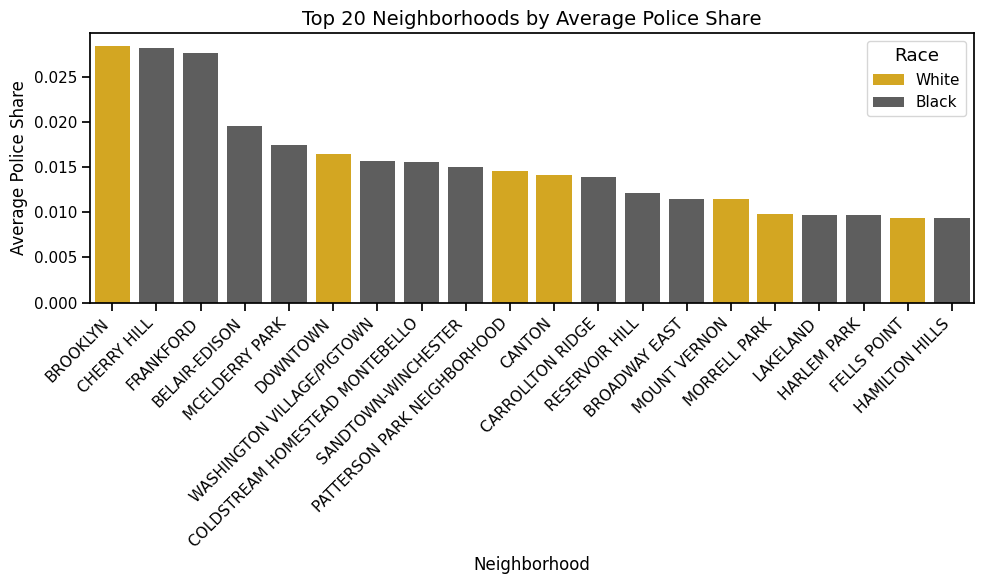

In [43]:
plot_neighborhood_stats(pMethod="Daily", pRep= 0.4, pNum= 400, cType="BURGLARY", alg="Pred")


We have looked at daily concentrations and the temporal trends of officer assignment shares to Black vs. White neighborhoods before. This time we are checking out average police share to the top 20 neighborhoods through out the days of the simulation.

### Questions this plot answers:
#### Aim 5: Baltimore-Specific Questions and Insights
**1. Are police consistently concentrated in racially defined neighborhoods (Black-majority, White-majority, or Other), and if so, which group receives more attention?**

Looking at this diagram over different scenarios, we see that when reported crimes are used (pReport = 0.4), with **burglary records**, PredPol's top 20 neighborhoods in terms of police share assigned are more balanced between black and white neighborhoods (13 to 7) compared to KDE(16 to 4), With Brooklyn, a white neighborhood, having the highest share (almost 0.03).
KDE, on the other hand, has Washington Village and Carrollton Ridge as the top 2, with about 0.05 and 0.04 police share, respectively.

Using **total crime records**, however, the top 20 neighborhoods in terms of average police share include as many Black neighborhoods as white, with Downtown, which is dominated by White resident getting twice as much of the share as others (about 0.035).

KDE is also having most of the officers focused in Downtown with a higher share compared to PredPol (almost 0.05). It is noticeably more imbalanced with a 12 to 8 ratio of Black to White neighborhoods in its top 20 assignments.

**2. Are these outcomes explainable by the number of neighborhoods per group, or do they reflect preferential targeting?**

yes, for this diagram more black neighborhoods could appear on top 20 because there are more of them in general in Baltimore

---


## Top 5 Neighborhoods and their percentage appearance (bar plot)

In this barplot we are checking out percentage of scenarios top 5 neighborhoods are appearing in each rank.

In [44]:
scenario_cols = ["Algorithm", "prediction_method", "crime_type", "number_of_police", "pReport"]

daily_master_df = master_df[master_df["prediction_method"]=="Daily"]

top_neigh_records = []
for scenario_id, group in daily_master_df.groupby(scenario_cols):
    grouped = group.groupby("Neighborhood").agg(
        avg_police_share=("police_share", "mean"),
        Race=("Race", "first")
    ).reset_index()
    
    grouped = grouped.sort_values("avg_police_share", ascending=False).head(5)
    grouped["Rank"] = range(1, len(grouped)+1)
    
    for _, row in grouped.iterrows():
        top_neigh_records.append({
            **dict(zip(scenario_cols, scenario_id)),
            "Neighborhood": row["Neighborhood"],
            "Rank": row["Rank"],
            "avg_police_share": row["avg_police_share"],
            "Race": row["Race"]
        })

top_neigh_df = pd.DataFrame(top_neigh_records)

def categorize_rank(rank):
    if rank == 1:
        return "Top 1"
    elif rank == 2:
        return "Top 2"
    else:
        return "Top 3–5"

top_neigh_df["RankCategory"] = top_neigh_df["Rank"].apply(categorize_rank)


display(top_neigh_df)

,Algorithm,prediction_method,crime_type,number_of_police,pReport,Neighborhood,Rank,avg_police_share,Race,RankCategory
0,KDE,Daily,BURGLARY,40,0.0,CARROLLTON RIDGE,1,0.048554,Black,Top 1
1,KDE,Daily,BURGLARY,40,0.0,WASHINGTON VILLAGE/PIGTOWN,2,0.043475,Black,Top 2
2,KDE,Daily,BURGLARY,40,0.0,BROOKLYN,3,0.036157,White,Top 3–5
3,KDE,Daily,BURGLARY,40,0.0,FRANKFORD,4,0.035515,Black,Top 3–5
4,KDE,Daily,BURGLARY,40,0.0,PATTERSON PARK NEIGHBORHOOD,5,0.033714,White,Top 3–5
...,...,...,...,...,...,...,...,...,...,...
75,Pred,Daily,TOTAL,400,0.4,DOWNTOWN,1,0.036581,White,Top 1
76,Pred,Daily,TOTAL,400,0.4,BELAIR-EDISON,2,0.023810,Black,Top 2
77,Pred,Daily,TOTAL,400,0.4,FRANKFORD,3,0.023706,Black,Top 3–5
78,Pred,Daily,TOTAL,400,0.4,CANTON,4,0.017702,White,Top 3–5


In [45]:

top_neigh_df_kde= top_neigh_df[top_neigh_df["Algorithm"]=="KDE"].copy()
total_scenarios_kde = len(top_neigh_df_kde[scenario_cols].drop_duplicates())

rank_stats_kde = (
    top_neigh_df_kde.groupby(["Neighborhood", "RankCategory"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ["Top 1", "Top 2", "Top 3–5"]:
    if col in rank_stats_kde.columns:
        if col== "Top 3–5":
            rank_stats_kde[f"{col}_pct"] = 100/3 * rank_stats_kde[col] / total_scenarios_kde
        else:
            rank_stats_kde[f"{col}_pct"] = 100 * rank_stats_kde[col] / total_scenarios_kde
    else:
        rank_stats_kde[col] = 0
        rank_stats_kde[f"{col}_pct"] = 0.0
display(rank_stats_kde)



RankCategory,Neighborhood,Top 1,Top 2,Top 3–5,Top 1_pct,Top 2_pct,Top 3–5_pct
0,BELAIR-EDISON,0,4,0,0.0,50.0,0.000000
1,BROOKLYN,0,0,6,0.0,0.0,25.000000
2,CARROLLTON RIDGE,2,2,0,25.0,25.0,0.000000
3,DOWNTOWN,4,0,2,50.0,0.0,8.333333
4,FRANKFORD,0,0,8,0.0,0.0,33.333333
5,PATTERSON PARK NEIGHBORHOOD,0,0,2,0.0,0.0,8.333333
6,SANDTOWN-WINCHESTER,0,0,2,0.0,0.0,8.333333
7,WASHINGTON VILLAGE/PIGTOWN,2,2,4,25.0,25.0,16.666667


In [46]:
top_neigh_df_pred= top_neigh_df[top_neigh_df["Algorithm"]=="Pred"].copy()
total_scenarios_pred = len(top_neigh_df_pred[scenario_cols].drop_duplicates())
rank_stats_pred = (
    top_neigh_df_pred.groupby(["Neighborhood", "RankCategory"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["Top 1", "Top 2", "Top 3–5"]:
    if col in rank_stats_pred.columns:
        if col == "Top 3–5":
            rank_stats_pred[f"{col}_pct"] = 100/3 * rank_stats_pred[col] / total_scenarios_pred
        else:
            rank_stats_pred[f"{col}_pct"] = 100 * rank_stats_pred[col] / total_scenarios_pred
    else:
        rank_stats_pred[col] = 0
        rank_stats_pred[f"{col}_pct"] = 0.0
display(rank_stats_pred)

RankCategory,Neighborhood,Top 1,Top 2,Top 3–5,Top 1_pct,Top 2_pct,Top 3–5_pct
0,BELAIR-EDISON,0,3,5,0.0,37.5,20.833333
1,BROOKLYN,3,0,5,37.5,0.0,20.833333
2,CANTON,0,0,2,0.0,0.0,8.333333
3,CHERRY HILL,1,3,2,12.5,37.5,8.333333
4,COLDSTREAM HOMESTEAD MONTEBELLO,0,0,1,0.0,0.0,4.166667
5,DOWNTOWN,4,0,1,50.0,0.0,4.166667
6,FRANKFORD,0,2,6,0.0,25.0,25.000000
7,MCELDERRY PARK,0,0,2,0.0,0.0,8.333333


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


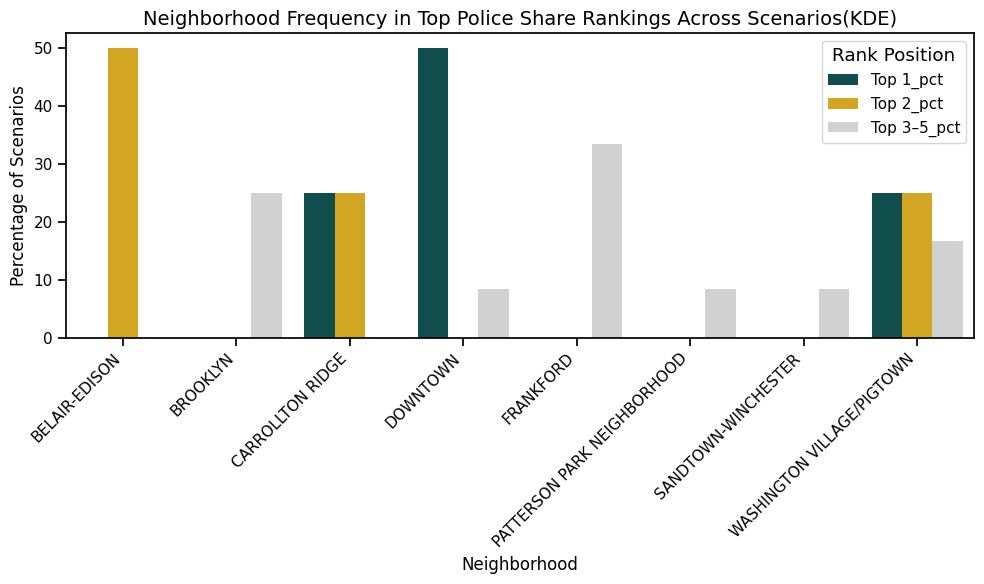

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


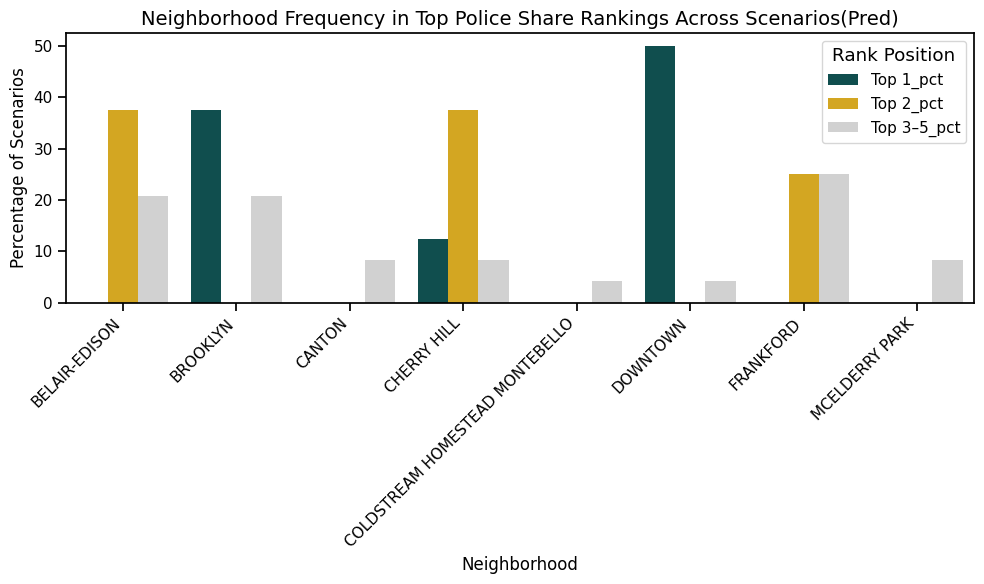

In [47]:
for algo,df in {"KDE":rank_stats_kde, "Pred":rank_stats_pred}.items():
    rank_long = df.melt(
        id_vars="Neighborhood",
        value_vars=["Top 1_pct", "Top 2_pct", "Top 3–5_pct"],
        var_name="Rank Position",
        value_name="Percentage"
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=rank_long,
        x="Neighborhood",
        y="Percentage",
        hue="Rank Position",
        palette=[COLORS[2],COLORS[0],COLORS[4]]
    )
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Neighborhood Frequency in Top Police Share Rankings Across Scenarios({algo})")
    plt.ylabel("Percentage of Scenarios")
    plt.xlabel("Neighborhood")
    plt.tight_layout()

    save_title = f'Top5HeavilyPoliced_Daily_{algo}'
    plt.savefig(f'{RRF}/{save_title}.png')
    plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
    plt.show()


### Questions this plot answers:
#### Aim 5: Baltimore-Specific Questions and Insights

**3. Are there specific neighborhoods that are consistently getting highest police-shares, regardless of the model used?**

As we look at the average police share throughout the days of the simulation in each scenario, using **KDE**, Downtown, Washington Village/Pigtown, and Carrollton are appearing as receiving top shares in about 50, 25, and 25 percent of scenarios, respectively. </br>
**PredPol** is also giving the highest share to Downtown, followed by Brooklyn and Cherry Hill, in about 50, 40, and 10 percent of scenarios, respectively.

**Second-ranked neighborhoods**, in order of number of appearances in different scenarios for **KDE**, are Blair-Edison, Carrollton Ridge, and Washington Village. </br>
For **PredPol**, the second ranks in order of appearance are  Cherry Hill, Blair-Edison, and Frankford.


## Comparing Weekly Individual-Fairness-Gap of neighborhoods in same clusters

In [48]:
import matplotlib.colors as mcolors
import colorsys

def hex_to_hsl(hex_color):
    rgb = mcolors.to_rgb(hex_color)
    return colorsys.rgb_to_hls(*rgb)  # returns (H, L, S)

def hsl_to_hex(h, l, s):
    rgb = colorsys.hls_to_rgb(h, l, s)
    return mcolors.to_hex(rgb)

def generate_palette_dict(neis, COLORS, variation_levels=3):
    neis = list(neis)
    palette_dict = {}

    base_hsl = [hex_to_hsl(c) for c in COLORS]
    used = 0
    total_colors = len(COLORS)

    for i, nei in enumerate(neis):
        base_idx = i % total_colors
        variant = i // total_colors

        h, l, s = base_hsl[base_idx]
        
        hue_shift = ((variant % variation_levels) - variation_levels // 2) * 0.02  # max shift ±0.02
        lightness_shift = 0.05 * ((variant // variation_levels) % 3 - 1)  # ±0.05 or 0
        sat_shift = -0.05 * ((variant // (variation_levels * 3)) % 2)  # 0 or -0.05

        new_h = (h + hue_shift) % 1
        new_l = min(0.85, max(0.25, l + lightness_shift))
        new_s = min(1, max(0.2, s + sat_shift))

        hex_color = hsl_to_hex(new_h, new_l, new_s)
        palette_dict[nei] = hex_color

    return palette_dict


In [49]:
daily_master= master_df[master_df['prediction_method']=="Daily"]

In [50]:
from sklearn.cluster import KMeans
def cluster_Neighborhoods_by_avgCrimeShare(cType):

    crime_master= daily_master[daily_master["crime_type"]==cType]
    
    crime_share_df = crime_master.groupby("Neighborhood").agg(
        avg_cShare=("crime_share", "mean"),
        Race=("Race", "first")  
    ).reset_index()

    kmeans = KMeans(n_clusters=5, random_state=42)
    crime_share_df["cluster"] = kmeans.fit_predict(crime_share_df[["avg_cShare"]])
    crime_share_df["cluster"] = (
        crime_share_df.groupby("cluster")["avg_cShare"]
        .transform("mean")
        .rank(method="dense")
        .astype(int)
    )


    plt.figure(figsize=(8, 4))
    sns.boxplot(data=crime_share_df, x="cluster", y="avg_cShare", palette= [COLORS[0]])
    plt.title(f"Neighborhood Clusters by Average Crime Share ({cType})")
    plt.ylabel("Average Crime Share")
    plt.xlabel("Cluster")
    plt.tight_layout()
    plt.show()

    race_counts = crime_share_df.groupby(["cluster", "Race"]).size().unstack(fill_value=0)
    #display(race_counts)
    race_percents = race_counts.div(race_counts.sum(axis=0), axis=1) * 100

    #display(race_percents)
    return crime_share_df


In [51]:
def plot_policeShare_weekly_Nei(pRep= 0.4, pNum= 40, cType="TOTAL", algo="Pred", c_group=1, weekly_Nei_df=weekly_Nei_df):
    
    c_share_df= cluster_Neighborhoods_by_avgCrimeShare(cType)

    neis= c_share_df[c_share_df["cluster"]== c_group]["Neighborhood"]
    
    p_dict = generate_palette_dict(neis, [COLORS[2], COLORS[0],COLORS[3], COLORS[4]])
    
    
    base_slice = weekly_Nei_df[
        (weekly_Nei_df["crime_type"] == cType) &
        (weekly_Nei_df["number_of_police"] == pNum) &
        (weekly_Nei_df["pReport"]==pRep)&
        (weekly_Nei_df["Algorithm"]==algo)&
        (weekly_Nei_df["Neighborhood"].isin(neis))
    ].copy()

    fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    sns.lineplot(
        data=base_slice,
        x="WeekLabel",
        y= "weekly_police_share", #"weekly_policeCrime_gap",
        hue="Neighborhood",
        ax=axs[0],
        palette=p_dict,
        errorbar = None
    )
    axs[0].set_title(f"Weekly Police-Share({algo})")
    axs[0].set_ylabel("Police-Share")

    sns.lineplot(
        data=base_slice,
        x="WeekLabel",
        y="weekly_detected_perc",
        hue="Neighborhood",
        ax=axs[1],
        palette=p_dict,
        errorbar = None
    )
    axs[1].set_title(f"Weekly Crime-Percentage Derected({algo})")
    axs[1].set_ylabel("Crime-Percentage Derected")

    plt.tight_layout()
    
    save_title = f'NeighborhoodCompare_Accuracy_Vs_PoliceShare_OverWeek_{algo}_{pRep}_{cType}_{pNum}_clus{c_group}'
    plt.savefig(f'{RRF}/{save_title}.png')
    plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
    plt.show()


### Using All Crime-Types

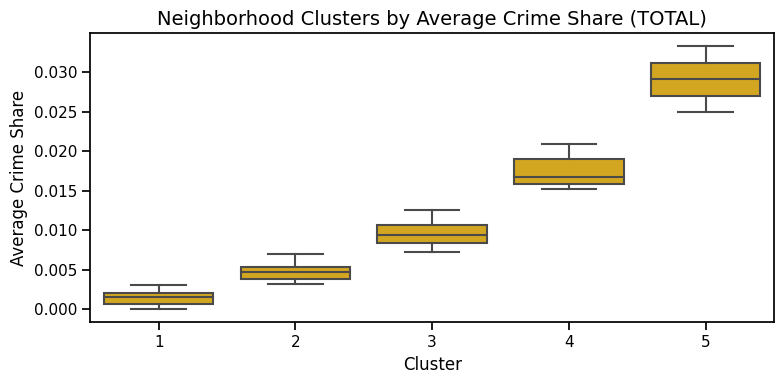

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


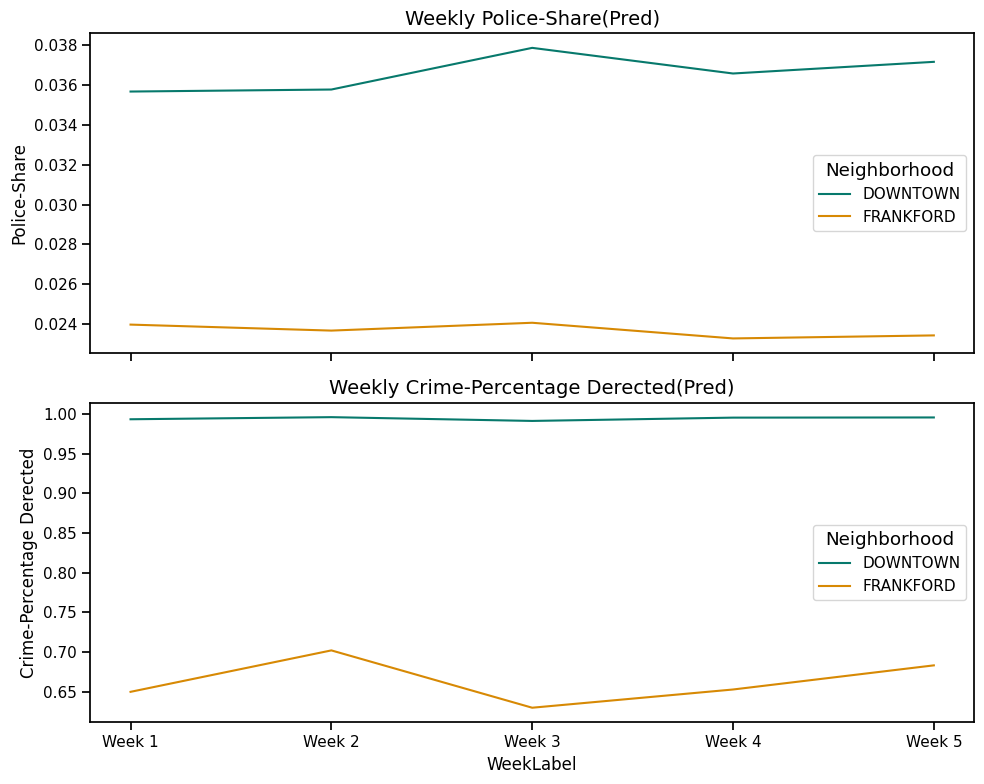

In [52]:
plot_policeShare_weekly_Nei(pRep= 0.4, pNum= 400, cType="TOTAL", algo="Pred", c_group=5)

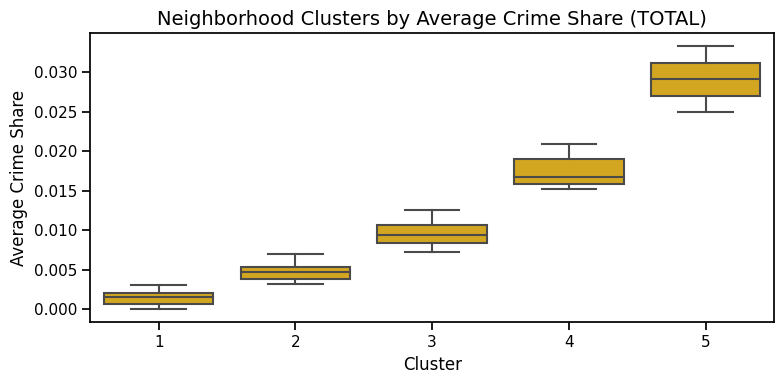

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


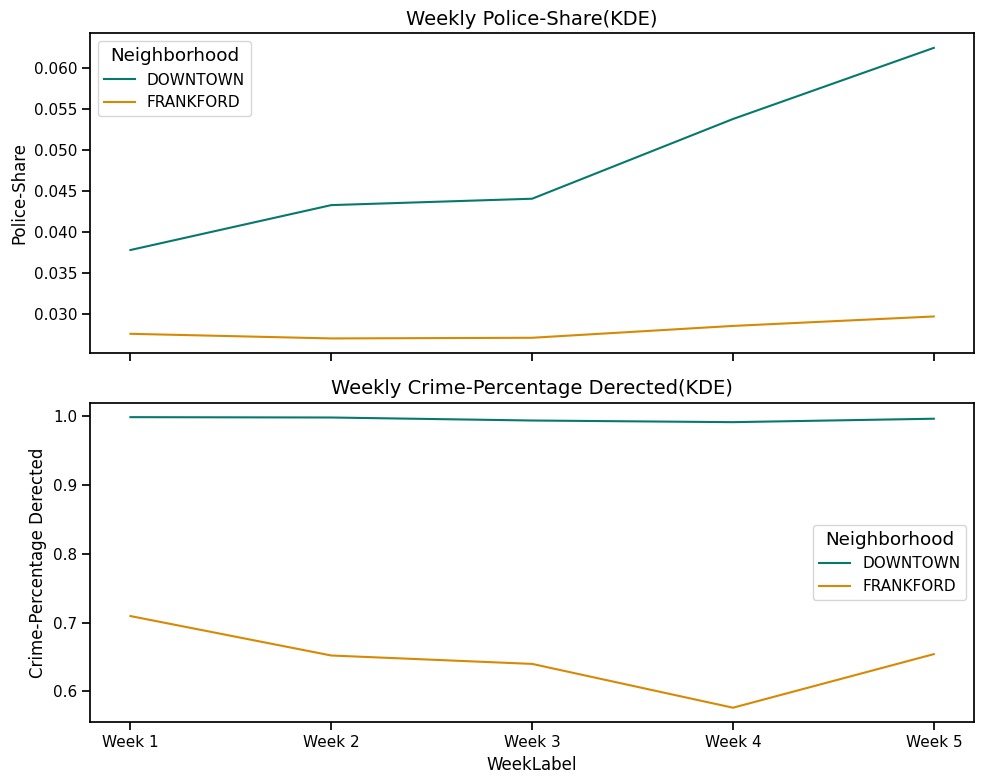

In [53]:
plot_policeShare_weekly_Nei(pRep= 0.4, pNum= 400, cType="TOTAL", algo="KDE", c_group=5)


when using **all crime records**, we see that both PrredPol and KDE are showing a difference in treatment of Frankford and Downtown. These neighborhoods are both in the cluster number 5, which have the highest average crime share. Downtown is a White neighborhood, while Frankford is Black. Both algorithm,  are assigning an increasing police share to Downtown over the weeks. The changes to police share for Frabkford are minor over the weeks in comparison to Downtown. It is especially obvious the extent of KDE's over-focusing on some neighborhoods is much more than PredPol. 

While Downtown is maintaining 100% coverage accuracy using either models, Frankford's coverage accuracy drops in the case of KDE, and fluctuates around 65 to 70% in the case of PredPol.

---

### Using Burglary Records

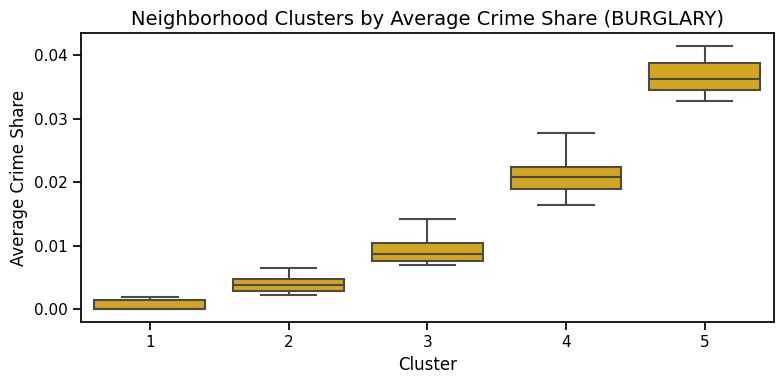

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


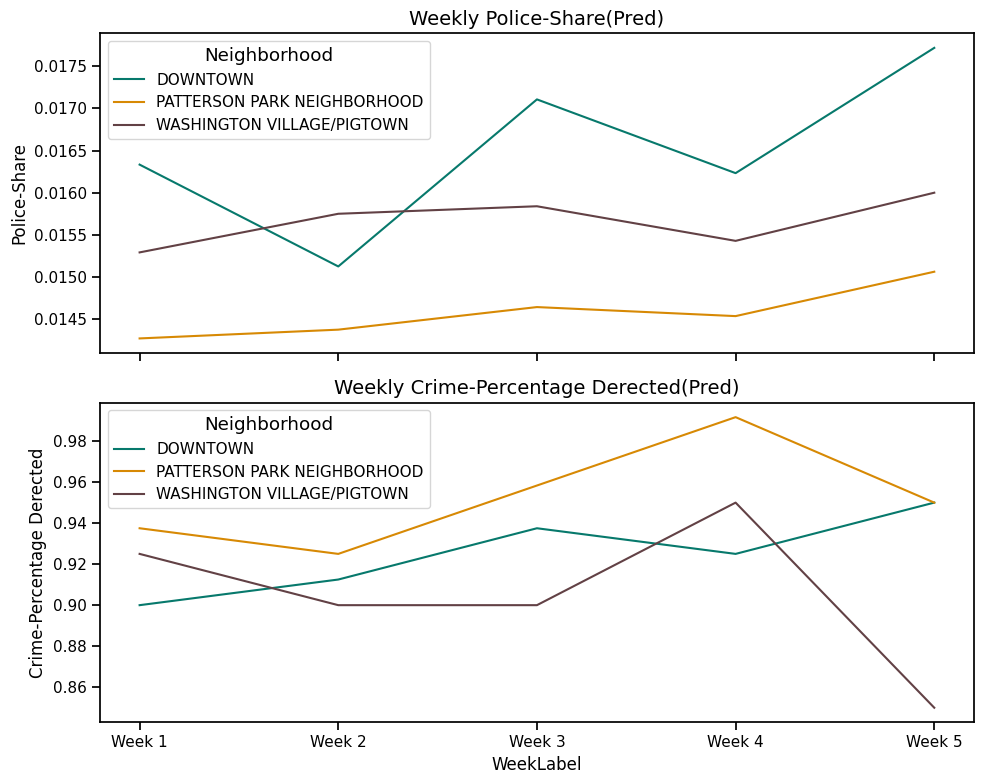

In [54]:
plot_policeShare_weekly_Nei(pRep= 0.4, pNum= 400, cType="BURGLARY", algo="Pred", c_group=5)

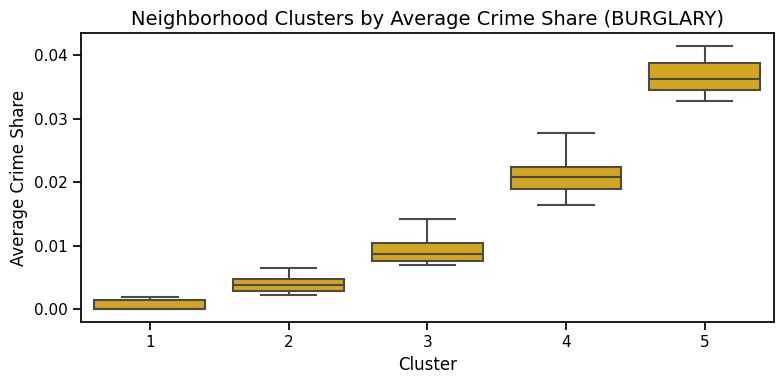

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


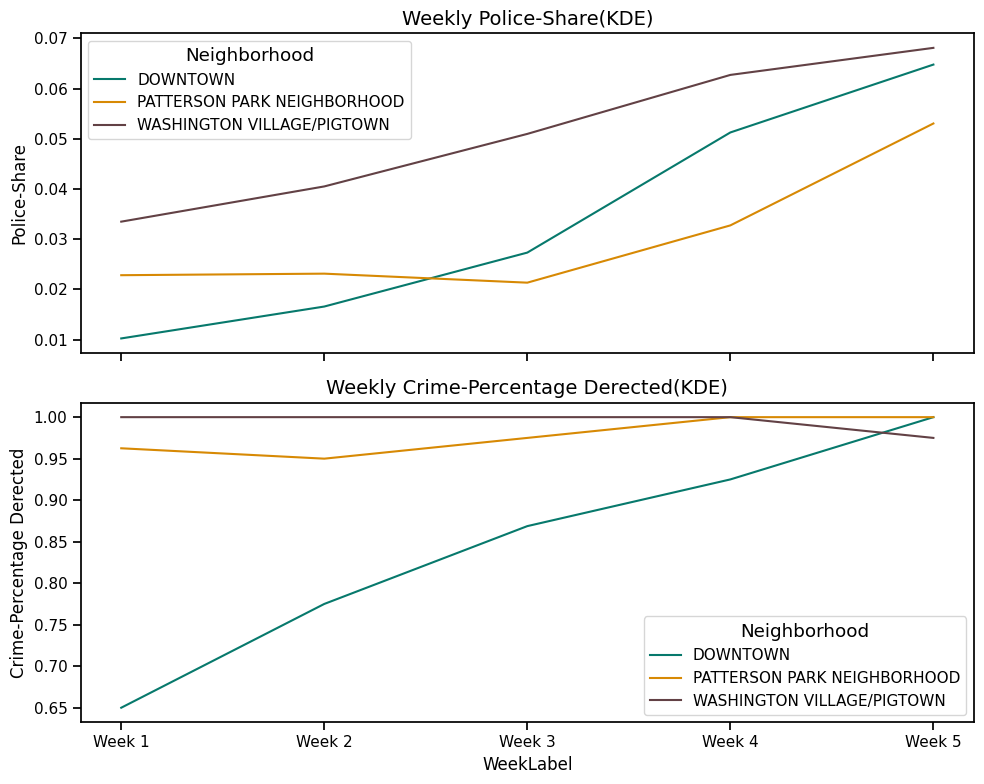

In [55]:
plot_policeShare_weekly_Nei(pRep= 0.4, pNum= 400, cType="BURGLARY", algo="KDE", c_group=5)

Using **burglary records**, again, the rise in police share among neighborhoods in cluster 5 is obvious in both models. Again, KDE's over-concentration is heavier than PredPol's. However, using burglaries, the neighborhood in a cluster are treated more alike compared to when all crime records were used.


---

## Results

**1. Fairness and Accuracy Comparison**

PredPol is generally **more accurate** than KDE across most scenarios.
In examining **racial fairness**, it was shown that PredPol was fairer in 75% of the scenarios .

**Individual fairness** varies: 
- in daily behavior comparison KDE is fairer in 62% of scenarios with an average margin of 0.038. However on the scenarios that PredPol is the fairer algorithm, the margine is higher (0.042).
- in weekly behavior comparison however, PredPol is again the fairer algorithm in 75% of scenarios by a margine of 0.093 on average.
Therefore in general PredPol is often fairer in the case of individual fairness as well.

Higher accuracy does not guarantee a fairer model (either racialy or individualy). Both fair and unfair outcomes were observed across the fairness spectrum for high-accuracy scenarios.

KDE in all scenarios, and PredPol in half of the scenarios, concentrated higher police-shares on Black neighborhoods on most of the days. However, contrary to prevailing wisdom the police-focus trends for KDE and PredPol were toward **White neighborhoods**, in 87.5% and 75% of scenarios respectively. 

**2. Temporal Feedback Loop Effects**

Bias does not always amplify, but when it does, it amplifies differently for the two algorithms. 

**Daily** trends of **racial fairness gap** demonstrated that PredPol in 75% of scenarios and KDE in 87.5% of scenarios had a rising fairness-gap trend (i.e., fairness dropped).  

**Daily** trends of **individual fairness gap** in a 30 day period of simulation showed a rise in the gap (lower fairness) for PredPol in **all** the sccenarios, while KDE experienced a rise only in **25%** off scenarios. </b>
While longer simulation time might bring out the bias amplification in the daily perspective of the other scenarios as well, examining the same results over the weekly perspective drew a more clear image of the individual fairness situation. 

**Weekly** trends of **individual fairness-Gap** showed an initial fall and then a rising trend of individual fairness gap. There seems to be a span of time in the start of simulation where the algorithm start assigning closer to neighborhoods crime-share but after a point over-policings and under-policing starts to accur. 

In terms of the speed of trend: 
- KDE often shows steeper trends in police concentration over time.
- PredPol tends to be more stable in its allocation patterns, showing less susceptibility to feedback loop amplification.

**3. Crime Type Effect**

Burglary-based models exhibit stronger racial bias than those using all crime types.
KDE is more sensitive to the choice of crime type than PredPol. For example, when using all crimes, KDE allocates more to White neighborhoods, but flips to Black neighborhoods when using burglaries.

**4. Data-Driven vs Model-Driven Bias**

Both data and model matter:
Same data fed into different models (KDE vs PredPol) produces different fairness outcomes.
Same model fed different data (burglary vs total crime) can flip the direction of bias.
KDE appears more data-sensitive, while PredPol exhibits more model-consistent behavior across different inputs.

**5. Baltimore-Specific Insights**

Black neighborhoods receive more police on average in most simulations—but this varies with crime type and algorithm.
In scenarios using all crime types, KDE with low officer numbers sometimes concentrates more police in White neighborhoods, especially when reporting is low.
These patterns are not solely explainable by neighborhood count (Baltimore has more Black than White neighborhoods), suggesting model behavior plays a larger role than geography alone.

**6. Neighborhood Consistency**

Downtown, Brooklyn, and Cherry Hill are repeatedly among the top neighborhoods receiving the highest police share.
This consistency across models suggests that some neighborhoods are structurally favored/targeted, regardless of the predictive algorithm.

## Conclusion
This study demonstrates that both model and training data effect fairness outcomes in algorithmic policing. While PredPol often provides higher accuracy and slightly more stable fairness trends, KDE's behavior is more variable and sensitive to crime type. 

The findings from Baltimore show that contrary to the generally believed bias trends, in these 30 day simulation scenarios, the police concentration trends were mostly toward White neighborhoods. Downtown Baltimore is a mostly White dominant area which appeared as the neighborhood recieving highest police shares (with a rising trend) in most of the simulation scenarios. Our results emphasize the need for localized fairness assessments, and cautious use of predictive policing tools in sensitive environments.

## References

[1] U.S. Equal Employment Opportunity Commission. (1979). *Uniform Guidelines on Employee Selection Procedures (UGESP)*. Federal Register, Vol. 44, No. 43. https://www.eeoc.gov/laws/guidance/questions-and-answers-about-uniform-guidelines-employee-selection-procedures

[2] Rahman, A., et al. (2022). *Towards a Unifying Fairness Framework*. arXiv:2209.03805.